In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('train.csv')
df.head()

,시점,품목명,품종명,거래단위,등급,평년 평균가격(원),평균가격(원)
0,201801상순,건고추,화건,30 kg,상품,381666.666667,590000.0
1,201801중순,건고추,화건,30 kg,상품,380809.666667,590000.0
2,201801하순,건고추,화건,30 kg,상품,380000.000000,590000.0
3,201802상순,건고추,화건,30 kg,상품,380000.000000,590000.0
4,201802중순,건고추,화건,30 kg,상품,376666.666667,590000.0


### 유효 데이터 비율

In [3]:
# 데이터 로드
df = pd.read_csv('train.csv')

# '평균가격(원)'이 0이거나 NaN인 경우를 실질적 결측치(Missing)로 정의
df['is_missing'] = (df['평균가격(원)'] == 0) | (df['평균가격(원)'].isna())

def get_summary_table(df, group_col):
    summary = df.groupby(group_col).agg(
        전체_개수=('평균가격(원)', 'count'),
        결측치_개수=('is_missing', 'sum')
    )
    # 비율 계산 (결측치 아닌 것 / 전체)
    summary['유효_데이터_비율(%)'] = ((summary['전체_개수'] - summary['결측치_개수']) / summary['전체_개수'] * 100).round(2)
    return summary

# 1. 품목별 요약
item_summary = get_summary_table(df, '품목명')

# 2. 품종별 요약
kind_summary = get_summary_table(df, '품종명')

print("--- [품목별 데이터 요약] ---")
display(item_summary.sort_values(by='유효_데이터_비율(%)'))

print("\n--- [품종별 데이터 요약] ---")
display(kind_summary.sort_values(by='유효_데이터_비율(%)'))

--- [품목별 데이터 요약] ---


,전체_개수,결측치_개수,유효_데이터_비율(%)
품목명,,,
무,4752,3055,35.71
감자,4752,2814,40.78
사과,720,399,44.58
건고추,1152,554,51.91
배,576,262,54.51
양파,9792,4188,57.23
대파,3024,951,68.55
배추,3744,490,86.91
깐마늘(국산),288,0,100.00



--- [품종별 데이터 요약] ---


,전체_개수,결측치_개수,유효_데이터_비율(%)
품종명,,,
조생양파,1152,1152,0.00
감자 조풍,576,576,0.00
홍감자,576,572,0.69
햇산양건,288,277,3.82
햇산화건,288,274,4.86
다발무,2736,2531,7.49
쓰가루,288,263,8.68
원황,288,260,9.72
대파 수입,144,123,14.58


In [4]:
# 품목별 요약 (내림차순 정렬)
item_summary_sorted = item_summary.sort_values(by='유효_데이터_비율(%)', ascending=False)

print("--- [품목별 데이터 요약: 유효 비율 높은 순] ---")
display(item_summary_sorted)

--- [품목별 데이터 요약: 유효 비율 높은 순] ---


,전체_개수,결측치_개수,유효_데이터_비율(%)
품목명,,,
깐마늘(국산),288,0,100.00
상추,576,0,100.00
배추,3744,490,86.91
대파,3024,951,68.55
양파,9792,4188,57.23
배,576,262,54.51
건고추,1152,554,51.91
사과,720,399,44.58
감자,4752,2814,40.78


In [5]:
# 품종별 요약 (품목명, 유효 비율 순으로 정렬)
# 먼저 품종 데이터에 품목명을 다시 연결합니다 (멀티 인덱스 활용)
kind_detailed = df.groupby(['품목명', '품종명']).agg(
    전체_개수=('평균가격(원)', 'count'),
    결측치_개수=('is_missing', 'sum')
).reset_index()

kind_detailed['유효_데이터_비율(%)'] = ((kind_detailed['전체_개수'] - kind_detailed['결측치_개수']) / kind_detailed['전체_개수'] * 100).round(2)

# 품목명은 가나다순, 그 안에서 비율은 높은 순으로 정렬
kind_detailed_sorted = kind_detailed.sort_values(by=['품목명', '유효_데이터_비율(%)'], ascending=[True, False])

print("\n--- [품목별-품종별 상세 데이터 요약] ---")
# 보시기 편하게 인덱스를 숨기고 출력합니다
display(kind_detailed_sorted.style.hide(axis='index'))


--- [품목별-품종별 상세 데이터 요약] ---


품목명,품종명,전체_개수,결측치_개수,유효_데이터_비율(%)
감자,감자 수미,576,0,100.000000
감자,감자,576,124,78.470000
감자,감자 대지,576,220,61.810000
감자,감자 수미(햇),576,328,43.060000
감자,감자 수입,144,98,31.940000
감자,감자 수미(저장),576,436,24.310000
감자,감자 두백,576,460,20.140000
감자,홍감자,576,572,0.690000
감자,감자 조풍,576,576,0.000000
건고추,화건,288,1,99.650000


In [39]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False

# 품목별 시나리오 1~3

### 1. 건고추
S1: 화건(target)만
S2: 화건(target), 양건

거래단위 모두 30kg로 같음

In [6]:
df[df['품목명'] == '건고추']['거래단위'].unique()

array(['30 kg'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\1408723786.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_df, x='시점', y='평균가격(원)', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
C:\Users\LG\AppData\Local\Temp\ipykernel_34720\1408723786.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='시나리오', y='평균가격(원)', ax=axes[1], palette='Set2')


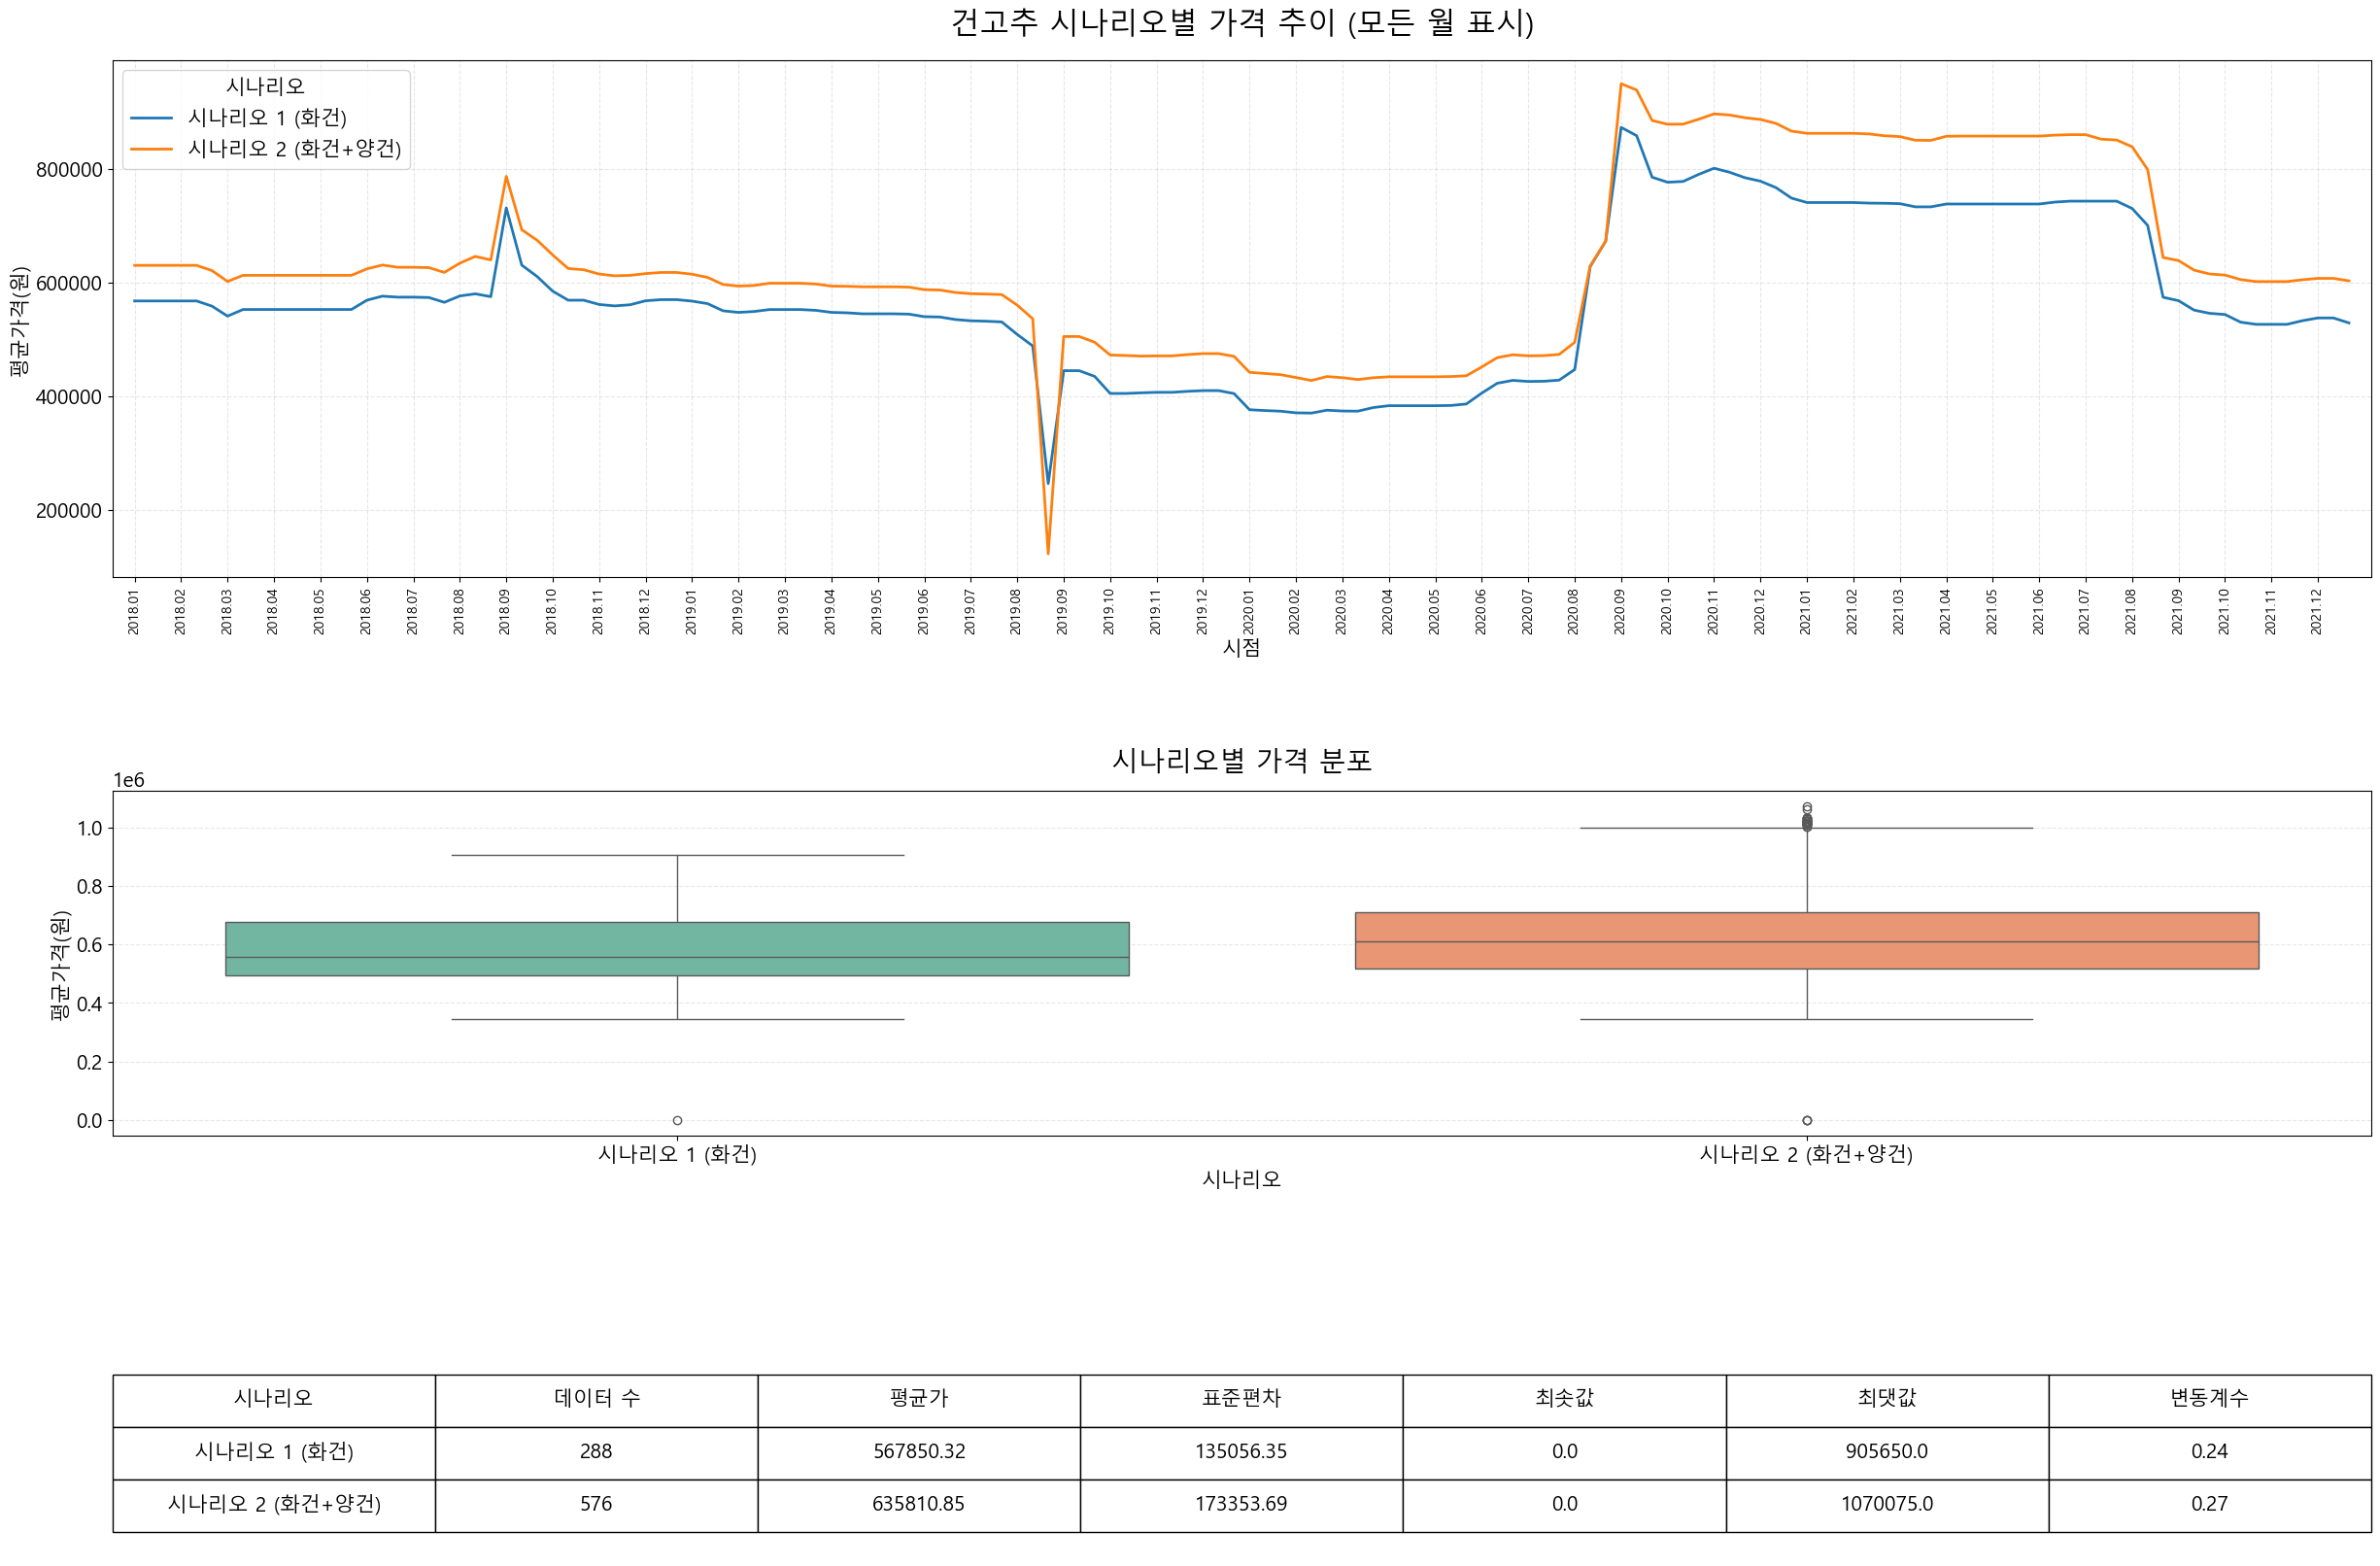

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비
s1_data = df[(df['품목명'] == '건고추') & (df['품종명'] == '화건')].copy()
s1_data['시나리오'] = '시나리오 1 (화건)'
s2_data = df[(df['품목명'] == '건고추') & (df['품종명'].isin(['화건', '양건']))].copy()
s2_data['시나리오'] = '시나리오 2 (화건+양건)'

combined_df = pd.concat([s1_data, s2_data])
combined_df['YearMonth'] = combined_df['시점'].str[:4] + "." + combined_df['시점'].str[4:6]

# 2. 시각화 설정 (가로로 매우 길게 설정하여 12개월이 다 보이게 함)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_df, x='시점', y='평균가격(원)', hue='시나리오', ax=axes[0], ci=None, linewidth=2)

# x축 설정: 모든 연도/월(상순 기준)을 리스트업
# 데이터가 너무 많아 겹칠 경우를 대비해 90도 회전
all_ticks = combined_df[combined_df['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)

axes[0].set_title('건고추 시나리오별 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01) # 좌우 여백 최소화

# --- [EDA 2] 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_df, x='시나리오', y='평균가격(원)', ax=axes[1], palette='Set2')
axes[1].set_title('시나리오별 가격 분포', fontsize=20, pad=15)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary = combined_df.groupby('시나리오')['평균가격(원)'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary['변동계수'] = (summary['std'] / summary['mean']).round(4)
summary.columns = ['시나리오', '데이터 수', '평균가', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary.round(2).values, 
                      colLabels=summary.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4)

plt.subplots_adjust(hspace=0.6) # 그래프 간 간격 확보
plt.show()

변동계수 시나리오1이 더 낮음 -> 화건(target)만으로

- 가격의 층 차이 -> 양건(햇볕 건조)은 화건(기계 건조)보다 보통 가격이 높음
- 변동성 -> 두개 섞었을때 그래프가 더 들쑥날쑥 => 품종간 가격차 큼

### 2. 사과
S1: 홍로, 후지 모두 (target 모두)
S2: 후지만 (target중 유효 비율이 높은)

단위: 10개당으로 모두 동일

In [19]:
df[df['품목명'] == '사과']['거래단위'].unique()

array(['10 개'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2418273009.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_apple, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2418273009.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_apple, x='시나리오', y='가격_kg', ax=axes[1], palette='husl')


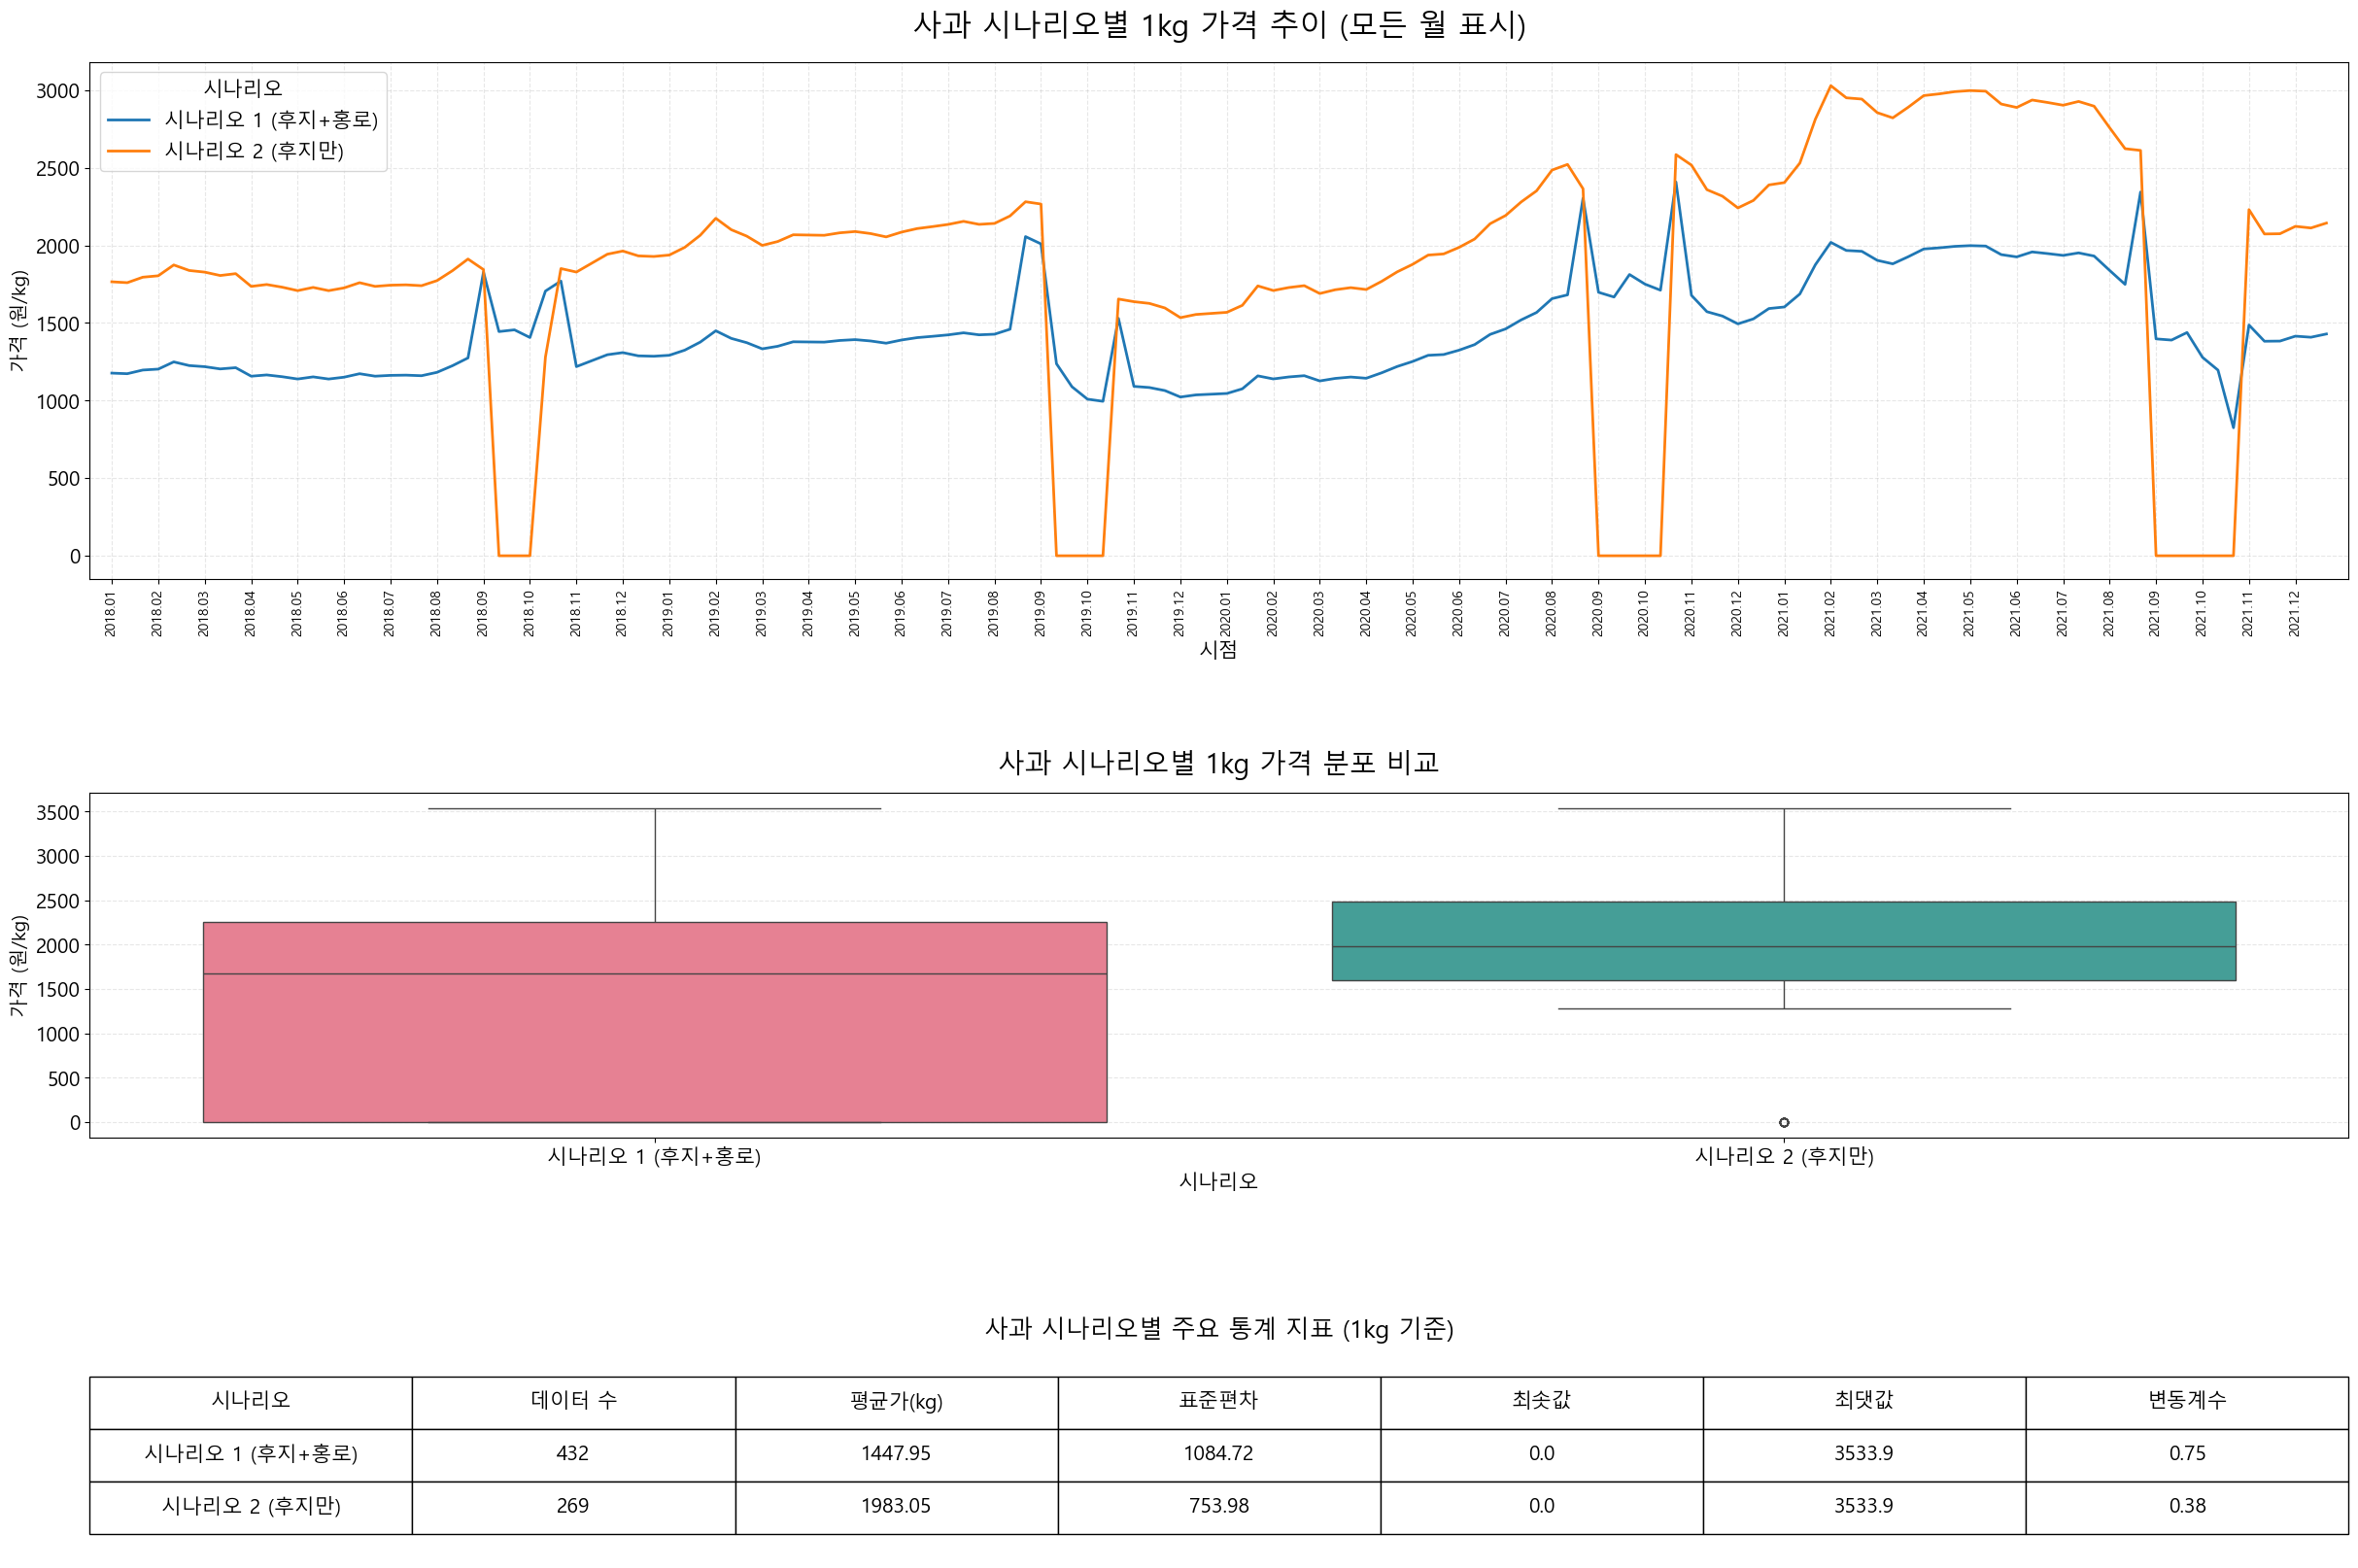

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 1kg당 가격 환산 함수 (사과 10kg 등 대응)
def convert_to_kg(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    # 단위에서 숫자만 추출 (ex: 10키로상자 -> 10)
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 사과 데이터 필터링 및 시나리오 생성
df_apple = df[df['품목명'] == '사과'].copy()
df_apple['가격_kg'] = df_apple.apply(convert_to_kg, axis=1)

# 시나리오 1: 후지, 홍로 모두 포함
s1_apple = df_apple[df_apple['품종명'].isin(['후지', '홍로'])].copy()
s1_apple['시나리오'] = '시나리오 1 (후지+홍로)'

# 시나리오 2: 후지만 포함
s2_apple = df_apple[df_apple['품종명'] == '후지'].copy()
s2_apple['시나리오'] = '시나리오 2 (후지만)'

combined_apple = pd.concat([s1_apple, s2_apple])
combined_apple['YearMonth'] = combined_apple['시점'].str[:4] + "." + combined_apple['시점'].str[4:6]

# 3. 시각화 (가로 30인치로 확장하여 1~12월 가독성 확보)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (1kg 단가 기준) ---
sns.lineplot(data=combined_apple, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
axes[0].set_title('사과 시나리오별 1kg 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전 (1~12월 노출)
all_ticks = combined_apple[combined_apple['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_apple, x='시나리오', y='가격_kg', ax=axes[1], palette='husl')
axes[1].set_title('사과 시나리오별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_apple = combined_apple.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_apple['변동계수'] = (summary_apple['std'] / summary_apple['mean']).round(4)
summary_apple.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_apple.round(2).values, 
                      colLabels=summary_apple.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4) 
axes[2].set_title('사과 시나리오별 주요 통계 지표 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

변동계수 더 작은 후지만 -> 다만 변동계수 30%이상으로 높음

- 계절적 공백 -> 홍로는 주로 9~10월에 집중, S2 => 홍로가 빠진 자리에 결측치로 인해 바닥

### 3. 감자
S1: 감자수미(target)만
S2: 감자수미(target), 감자, 감자대지(유효비율 높은)

In [20]:
df[df['품목명'] == '감자']['거래단위'].unique()

array(['20키로상자', '10키로상자', '23키로상자'], dtype=object)

In [24]:
df[(df['품목명'] == '감자') & (df['품종명']=='감자 수미')]['거래단위'].unique()

array(['20키로상자'], dtype=object)

In [25]:
df[(df['품목명'] == '감자') & (df['품종명']=='감자')]['거래단위'].unique()

array(['20키로상자'], dtype=object)

In [26]:
df[(df['품목명'] == '감자') & (df['품종명']=='감자 대지')]['거래단위'].unique()

array(['20키로상자'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2288403482.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_potato, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2288403482.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_potato, x='시나리오', y='가격_kg', ax=axes[1], palette='Set3')


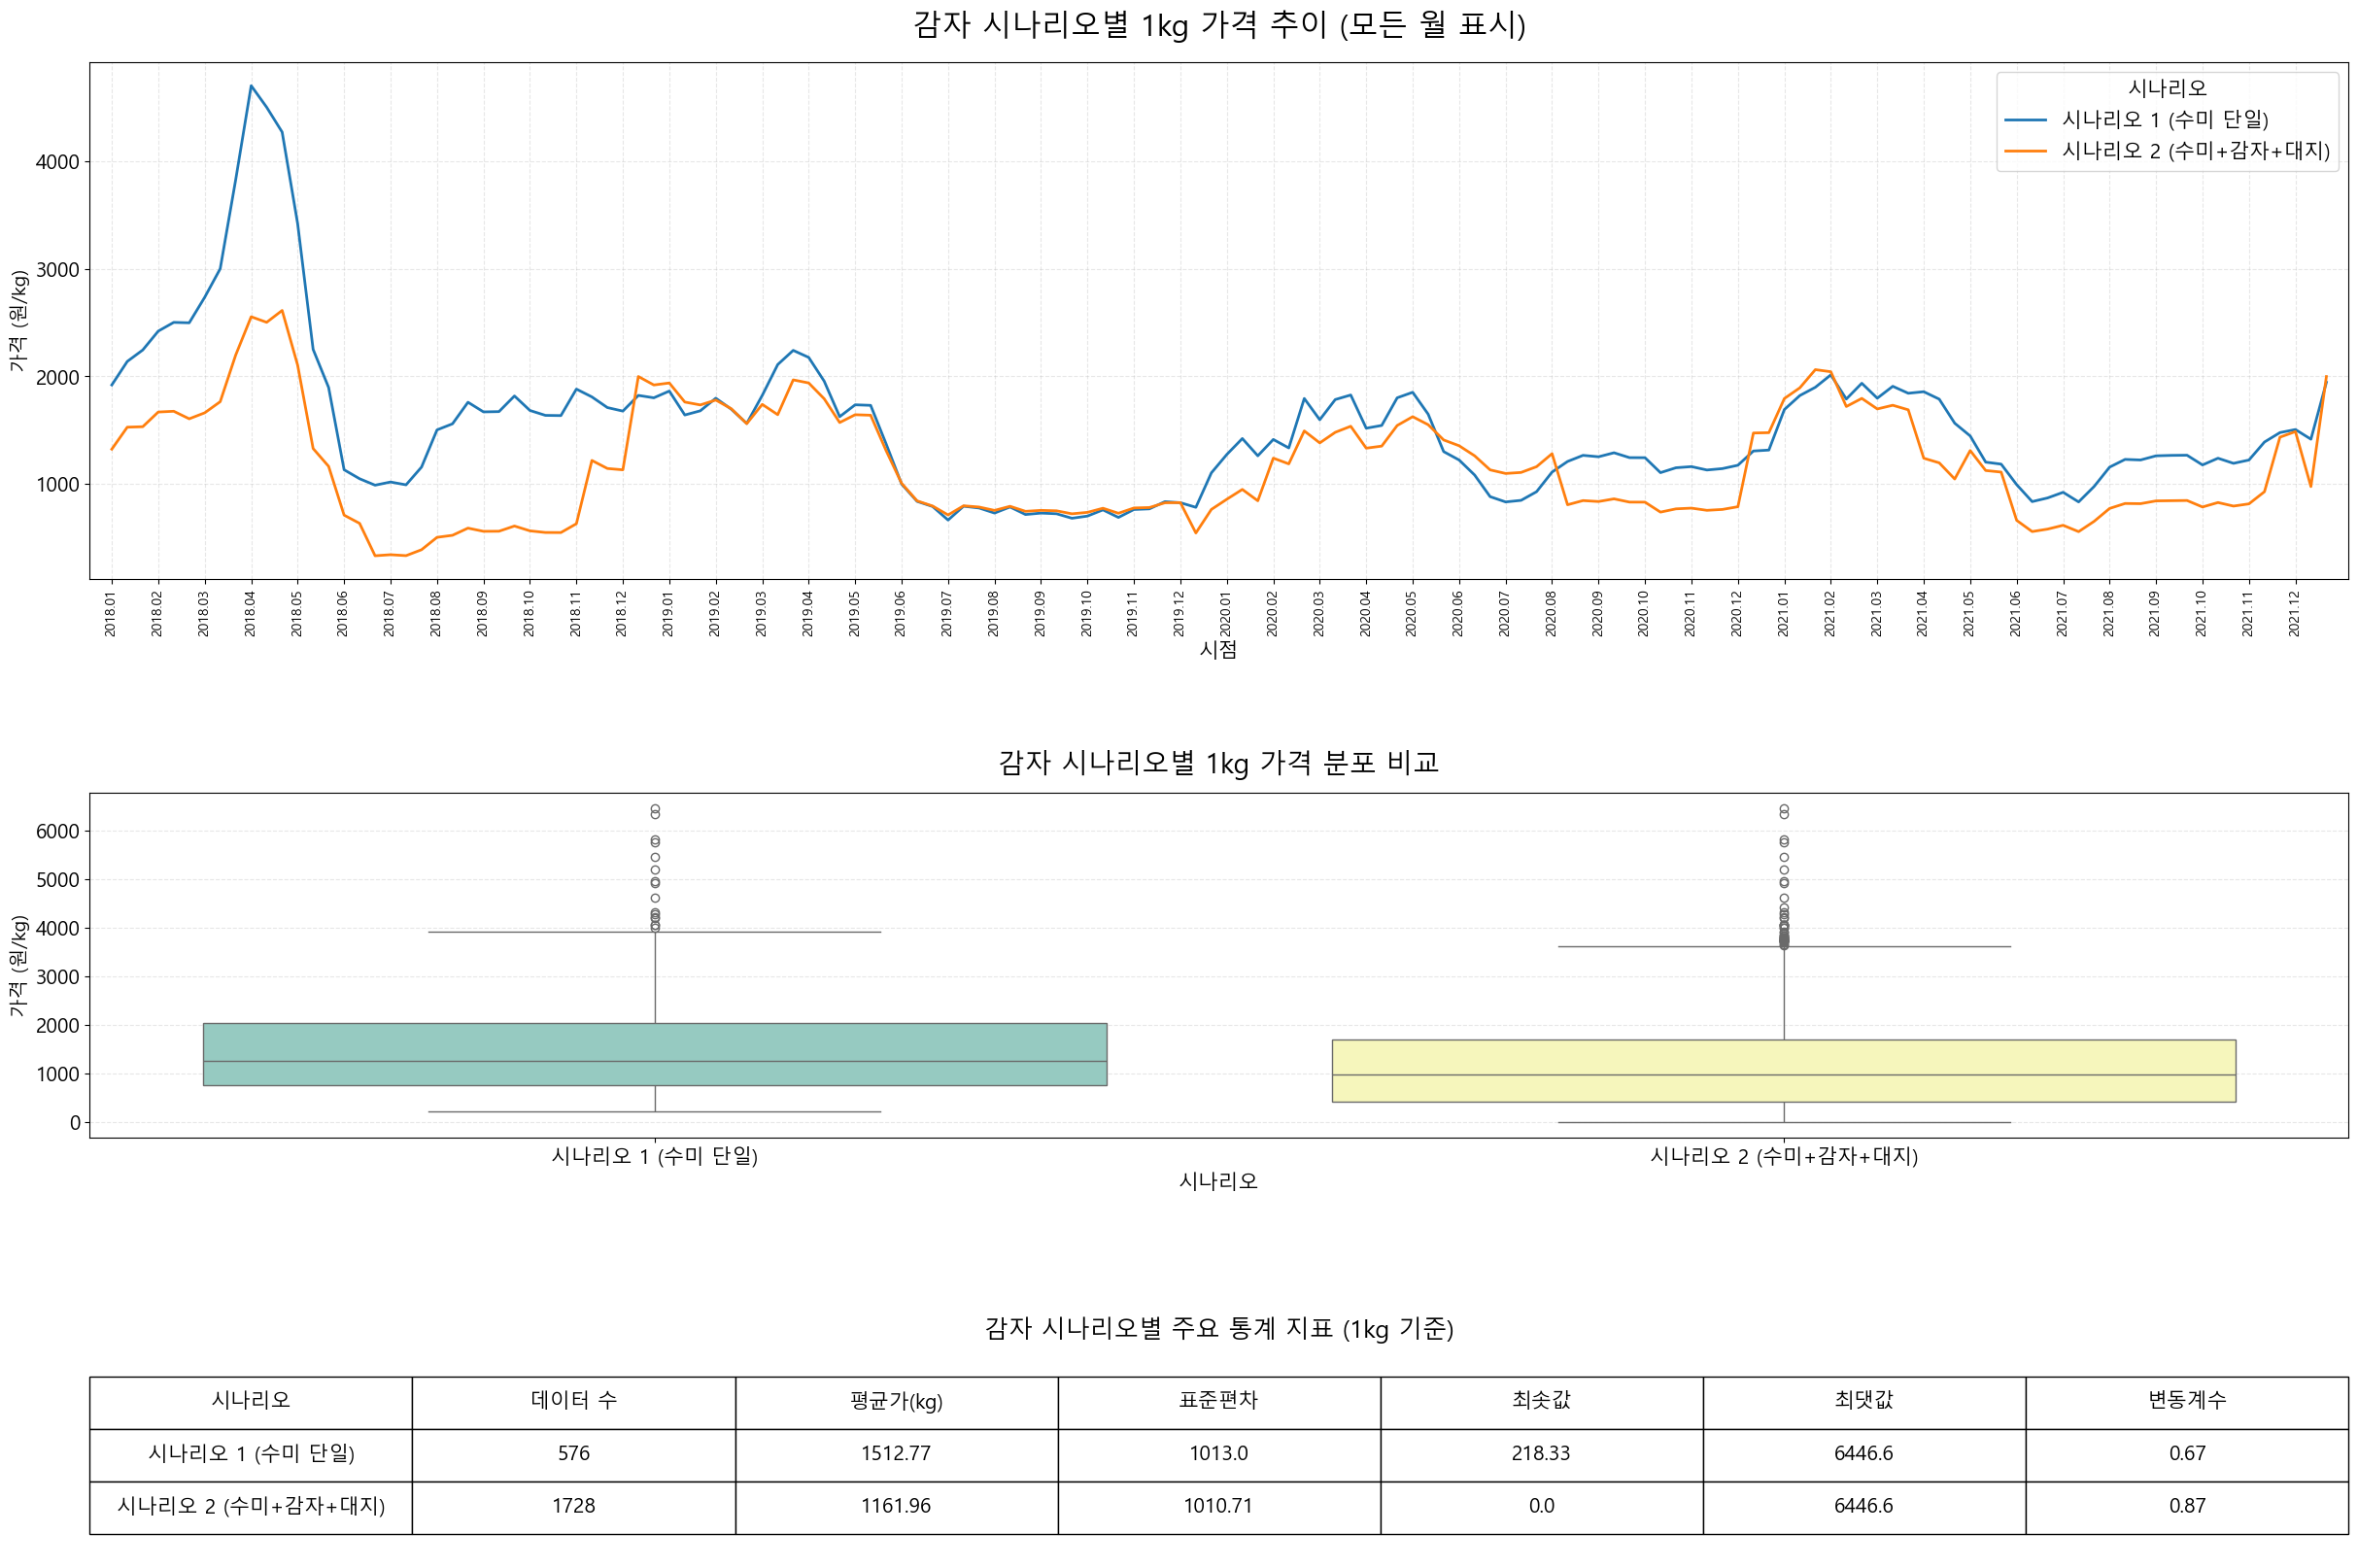

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 1kg당 가격 환산 함수
def convert_to_kg(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    # 단위에서 숫자 추출 (ex: 20키로상자 -> 20)
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 감자 데이터 필터링 및 시나리오 생성
df_potato = df[df['품목명'] == '감자'].copy()
df_potato['가격_kg'] = df_potato.apply(convert_to_kg, axis=1)

# 시나리오 1: 감자 수미만 포함
s1_potato = df_potato[df_potato['품종명'] == '감자 수미'].copy()
s1_potato['시나리오'] = '시나리오 1 (수미 단일)'

# 시나리오 2: 감자 수미, 감자, 감자 대지 포함
s2_potato = df_potato[df_potato['품종명'].isin(['감자 수미', '감자', '감자 대지'])].copy()
s2_potato['시나리오'] = '시나리오 2 (수미+감자+대지)'

combined_potato = pd.concat([s1_potato, s2_potato])
combined_potato['YearMonth'] = combined_potato['시점'].str[:4] + "." + combined_potato['시점'].str[4:6]

# 3. 시각화 (가로 30인치로 확장하여 가독성 극대화)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (1kg 단가 기준) ---
sns.lineplot(data=combined_potato, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
axes[0].set_title('감자 시나리오별 1kg 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_potato[combined_potato['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_potato, x='시나리오', y='가격_kg', ax=axes[1], palette='Set3')
axes[1].set_title('감자 시나리오별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_potato = combined_potato.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_potato['변동계수'] = (summary_potato['std'] / summary_potato['mean']).round(4)
summary_potato.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_potato.round(2).values, 
                      colLabels=summary_potato.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4) 
axes[2].set_title('감자 시나리오별 주요 통계 지표 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

둘다 변동계수 높음

- 품종 섞었을때 변동계수 높아짐 -> 품종간 가격차이 큼

### 4. 배
S1: 신고(target)만

In [28]:
df[(df['품목명'] == '배') & (df['품종명']=='신고')]['거래단위'].unique()

array(['10 개'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2324279664.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_pear, x='Year', y='가격_kg', ax=axes[1], palette='YlOrBr')


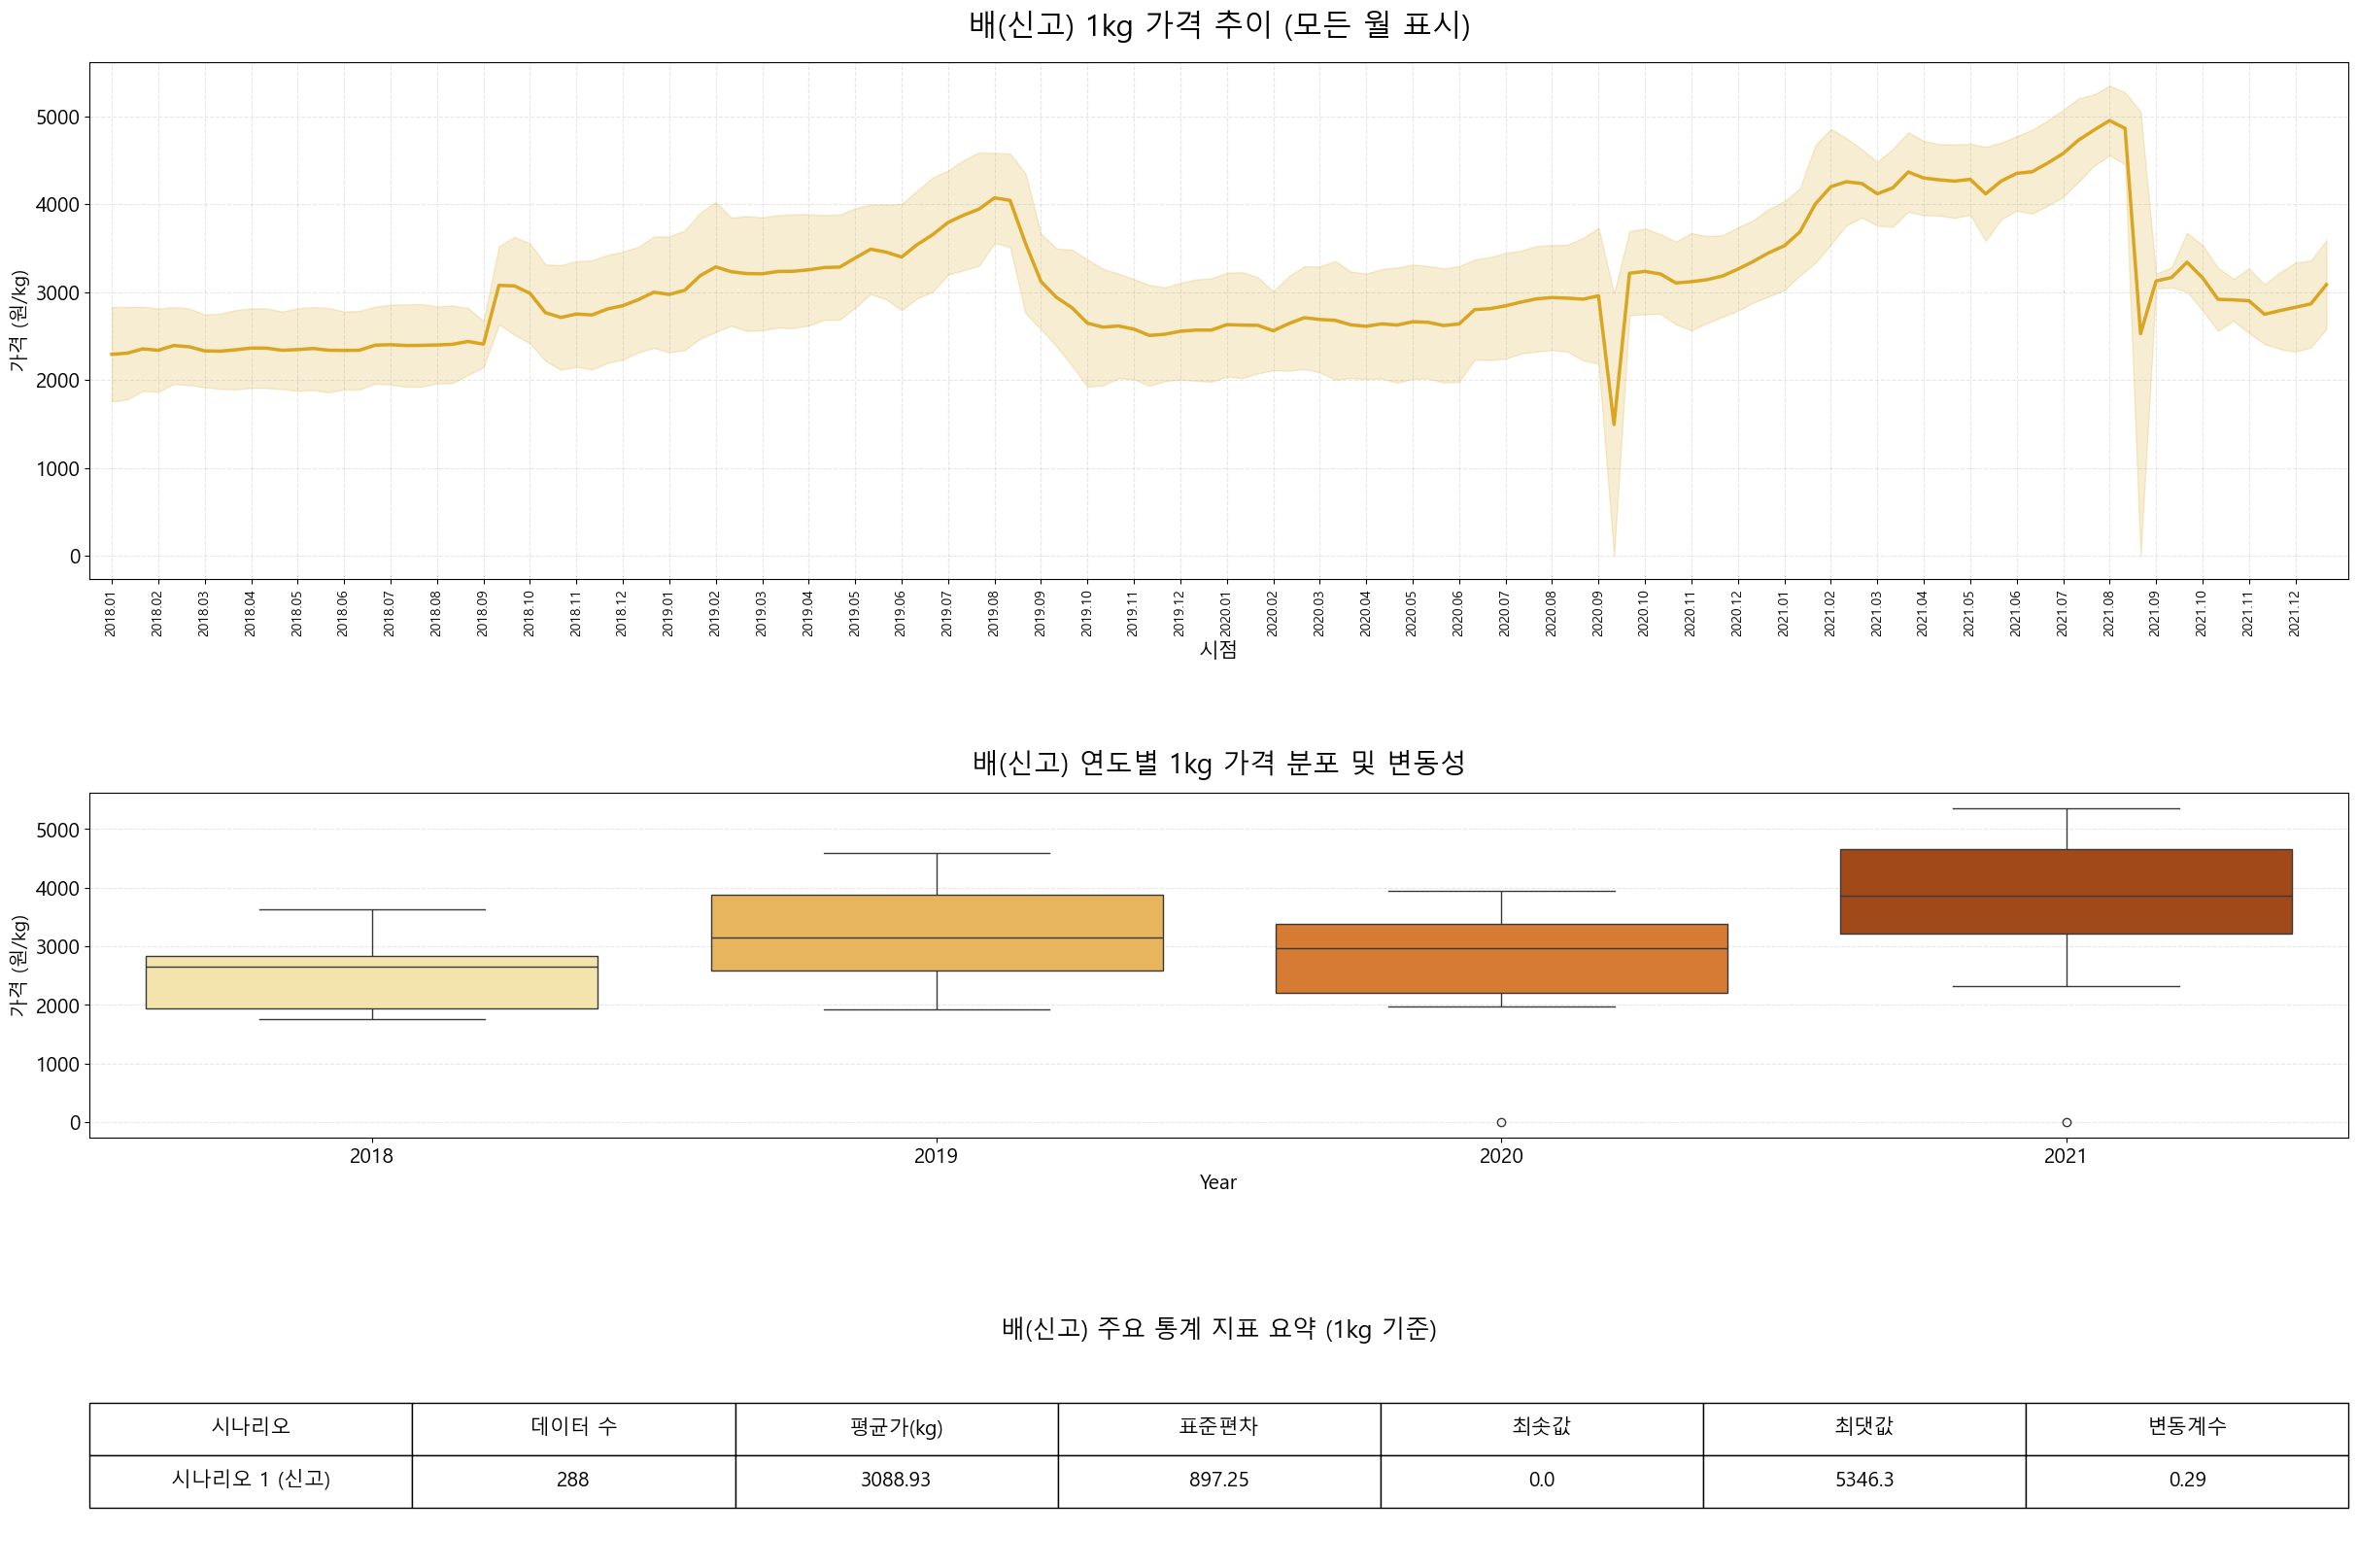

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 1kg당 가격 환산 함수
def convert_to_kg(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    # 단위에서 숫자 추출 (ex: 15키로상자 -> 15)
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 배 데이터 필터링 및 시나리오 생성
df_pear = df[df['품목명'] == '배'].copy()
df_pear['가격_kg'] = df_pear.apply(convert_to_kg, axis=1)

# 시나리오 1: 신고 품종만 포함
s1_pear = df_pear[df_pear['품종명'] == '신고'].copy()
s1_pear['시나리오'] = '시나리오 1 (신고)'

combined_pear = s1_pear
combined_pear['YearMonth'] = combined_pear['시점'].str[:4] + "." + combined_pear['시점'].str[4:6]
combined_pear['Year'] = combined_pear['시점'].str[:4]

# 3. 시각화 설정 (가로 30인치 확장)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (1kg 단가 기준, 모든 월 노출) ---
sns.lineplot(data=combined_pear, x='시점', y='가격_kg', ax=axes[0], color='goldenrod', linewidth=2.5)
axes[0].set_title('배(신고) 1kg 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 연도/월(상순 기준)을 리스트업하여 90도 회전
all_ticks = combined_pear[combined_pear['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 (Boxplot) ---
sns.boxplot(data=combined_pear, x='Year', y='가격_kg', ax=axes[1], palette='YlOrBr')
axes[1].set_title('배(신고) 연도별 1kg 가격 분포 및 변동성', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_pear = combined_pear.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_pear['변동계수'] = (summary_pear['std'] / summary_pear['mean']).round(4)
summary_pear.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_pear.round(2).values, 
                      colLabels=summary_pear.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4) 
axes[2].set_title('배(신고) 주요 통계 지표 요약 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

변동계수 30% 미만

- 명절효과 -> 매년 특정 시기(9~10월)에 가격 올랐다 급락하는 패턴

### 5. 깐마늘(국산)
S1: 깐마늘(target)

In [30]:
df[(df['품목명'] == '깐마늘(국산)') & (df['품종명']=='깐마늘(국산)')]['거래단위'].unique()

array(['20 kg'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2821560593.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_df, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)


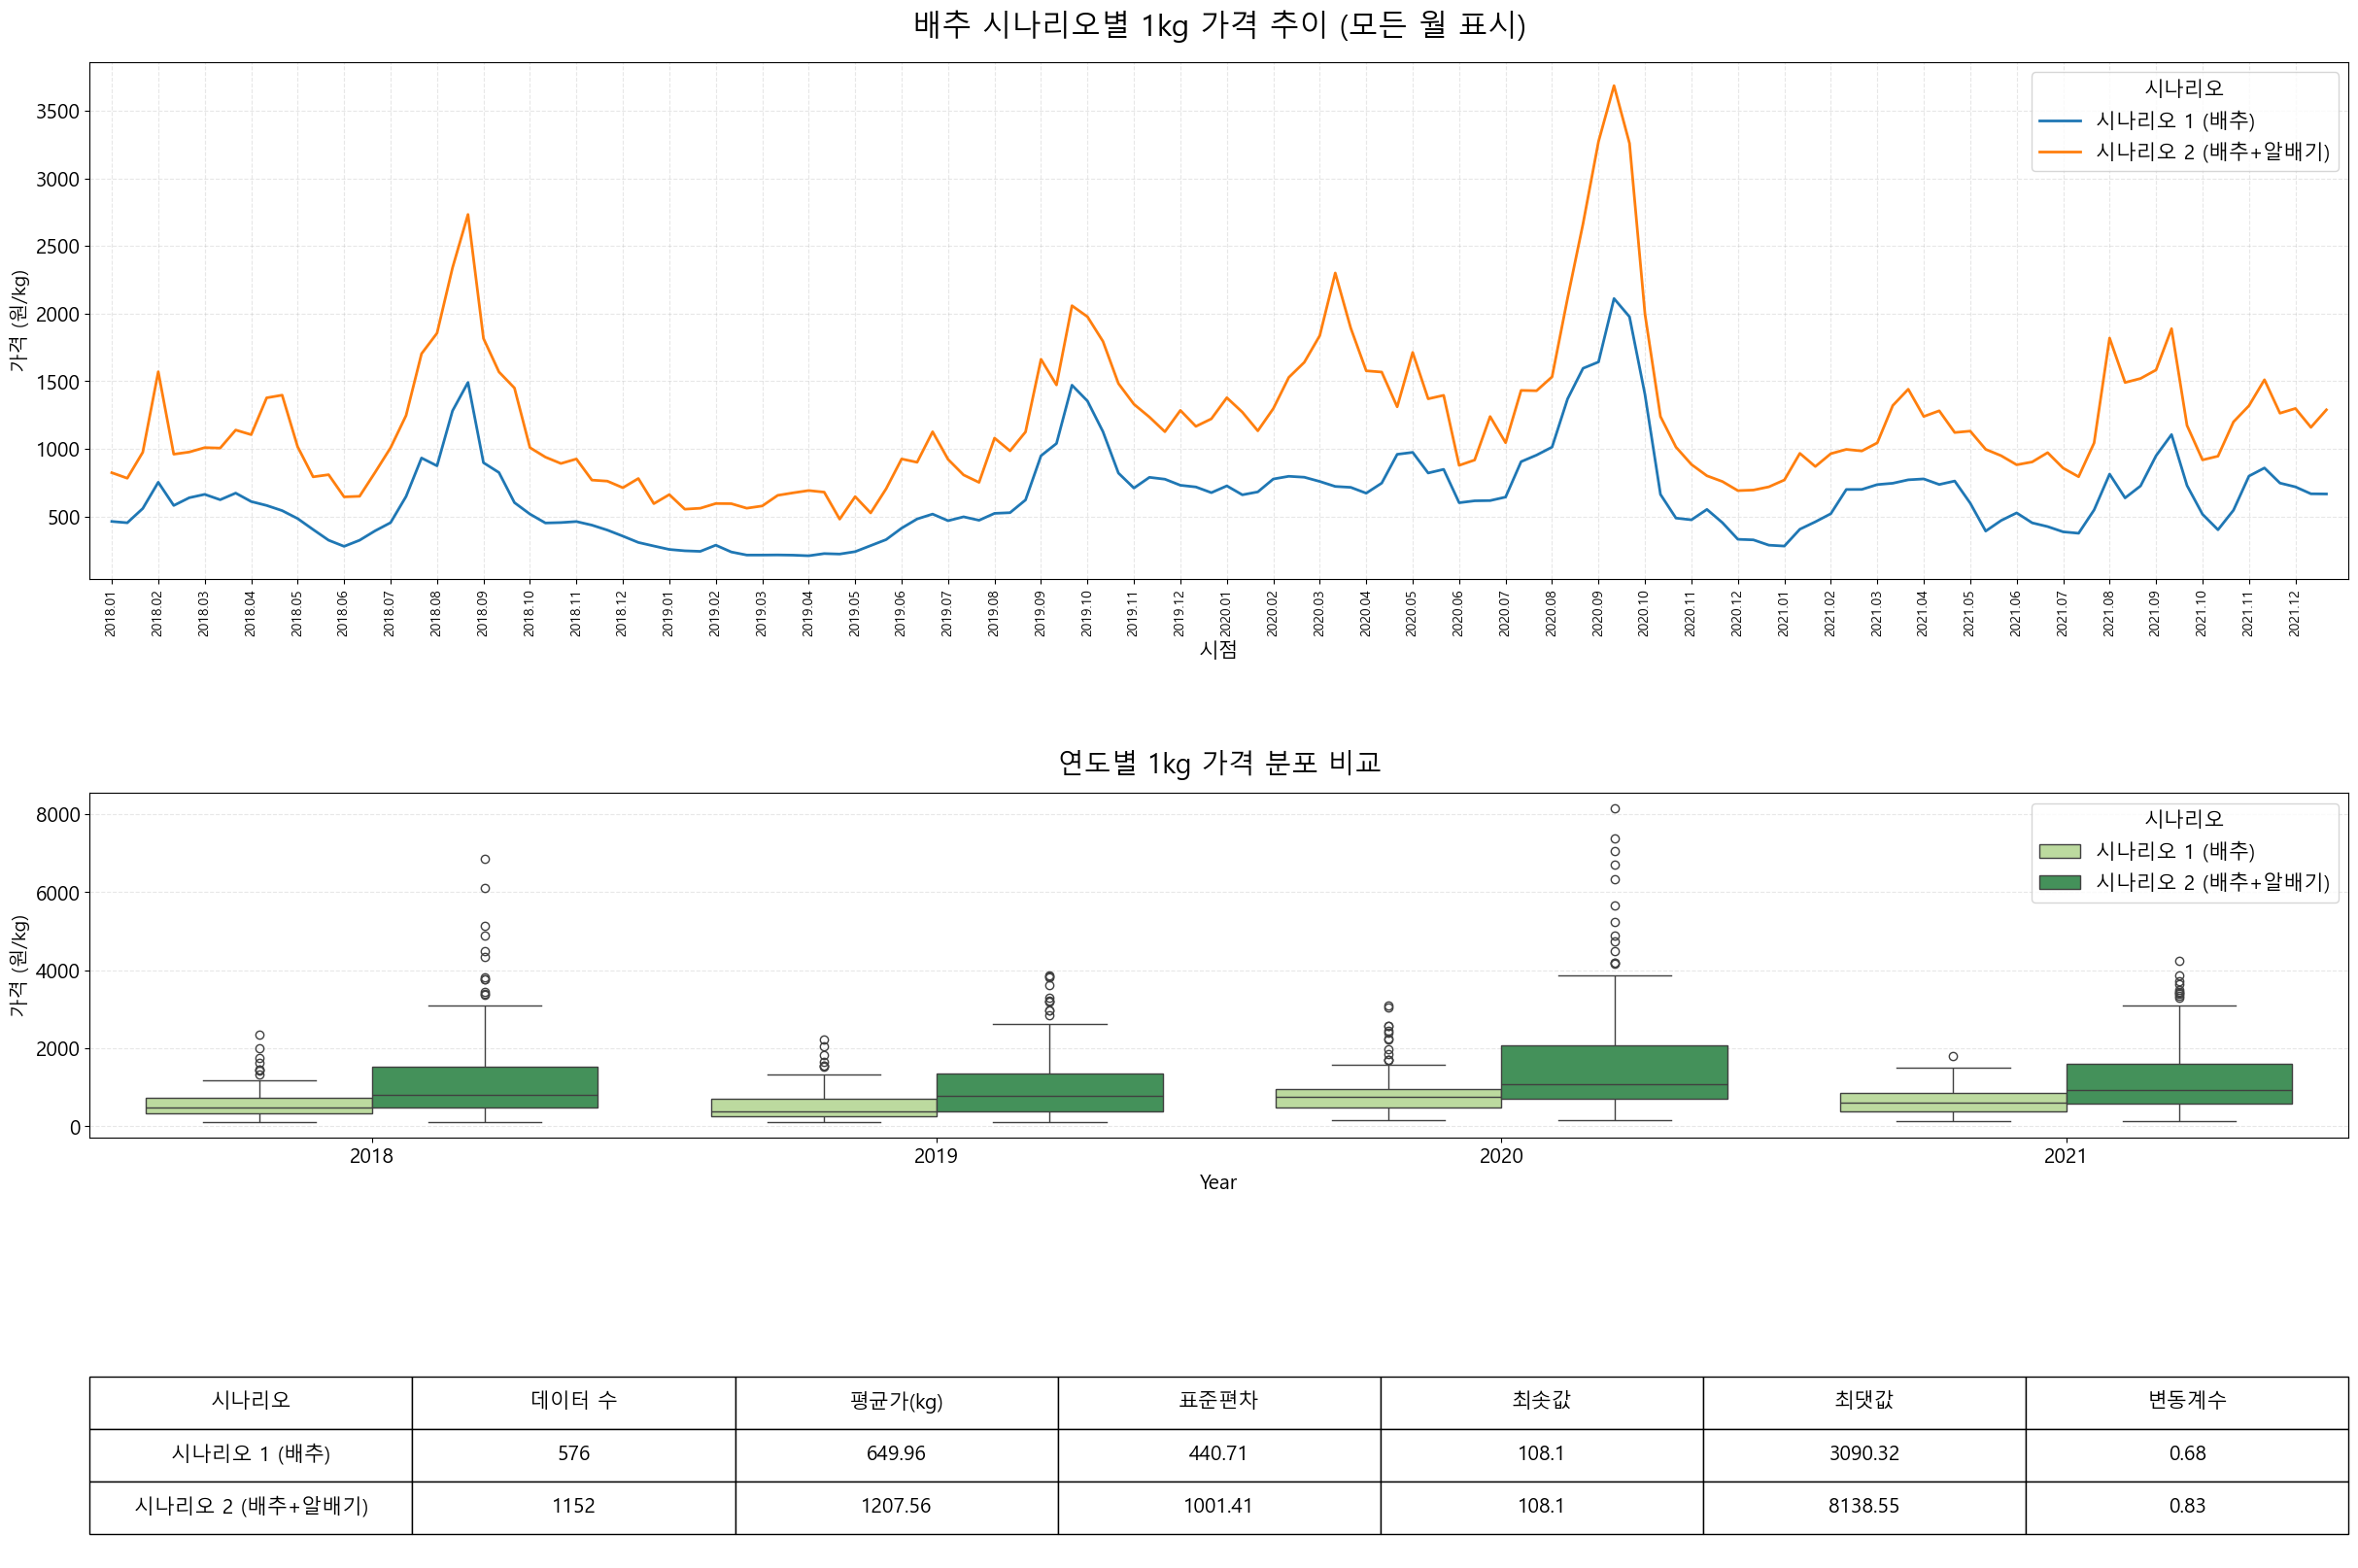

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. 1kg당 가격 환산 함수
def convert_to_kg(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 시나리오 생성 (배추 예시)
df_item = df[df['품목명'] == '배추'].copy()
df_item['가격_kg'] = df_item.apply(convert_to_kg, axis=1)

# 시나리오 설정
s1 = df_item[df_item['품종명'] == '배추'].copy()
s1['시나리오'] = '시나리오 1 (배추)'

s2 = df_item[df_item['품종명'].isin(['배추', '알배기배추'])].copy()
s2['시나리오'] = '시나리오 2 (배추+알배기)'

combined_df = pd.concat([s1, s2])
combined_df['YearMonth'] = combined_df['시점'].str[:4] + "." + combined_df['시점'].str[4:6]
combined_df['Year'] = combined_df['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장, 변곡점 없이 클린하게)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (1kg 단가 기준) ---
sns.lineplot(data=combined_df, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
axes[0].set_title('배추 시나리오별 1kg 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_df[combined_df['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 (Boxplot) ---
sns.boxplot(data=combined_df, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='YlGn')
axes[1].set_title('연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary = combined_df.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary['변동계수'] = (summary['std'] / summary['mean']).round(4)
summary.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary.round(2).values, 
                      colLabels=summary.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4)

plt.subplots_adjust(hspace=0.6)
plt.show()

- 2019년 중순에 급락 -> 2020년 중순 급등 -> 이후 계속 상승추세

### 6. 무
S1: 무(target)
S2: 무(target), 열무(유효값 높은)

In [33]:
df[(df['품목명'] == '무') & (df['품종명']=='무')]['거래단위'].unique()

array(['20키로상자', '18키로상자(비닐포)'], dtype=object)

In [34]:
df[(df['품목명'] == '무') & (df['품종명']=='열무')]['거래단위'].unique()

array(['4키로상자', '1.5키로단'], dtype=object)

단위 상이 -> 1kg 기준으로 맞추기

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2534438151.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_radish, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)


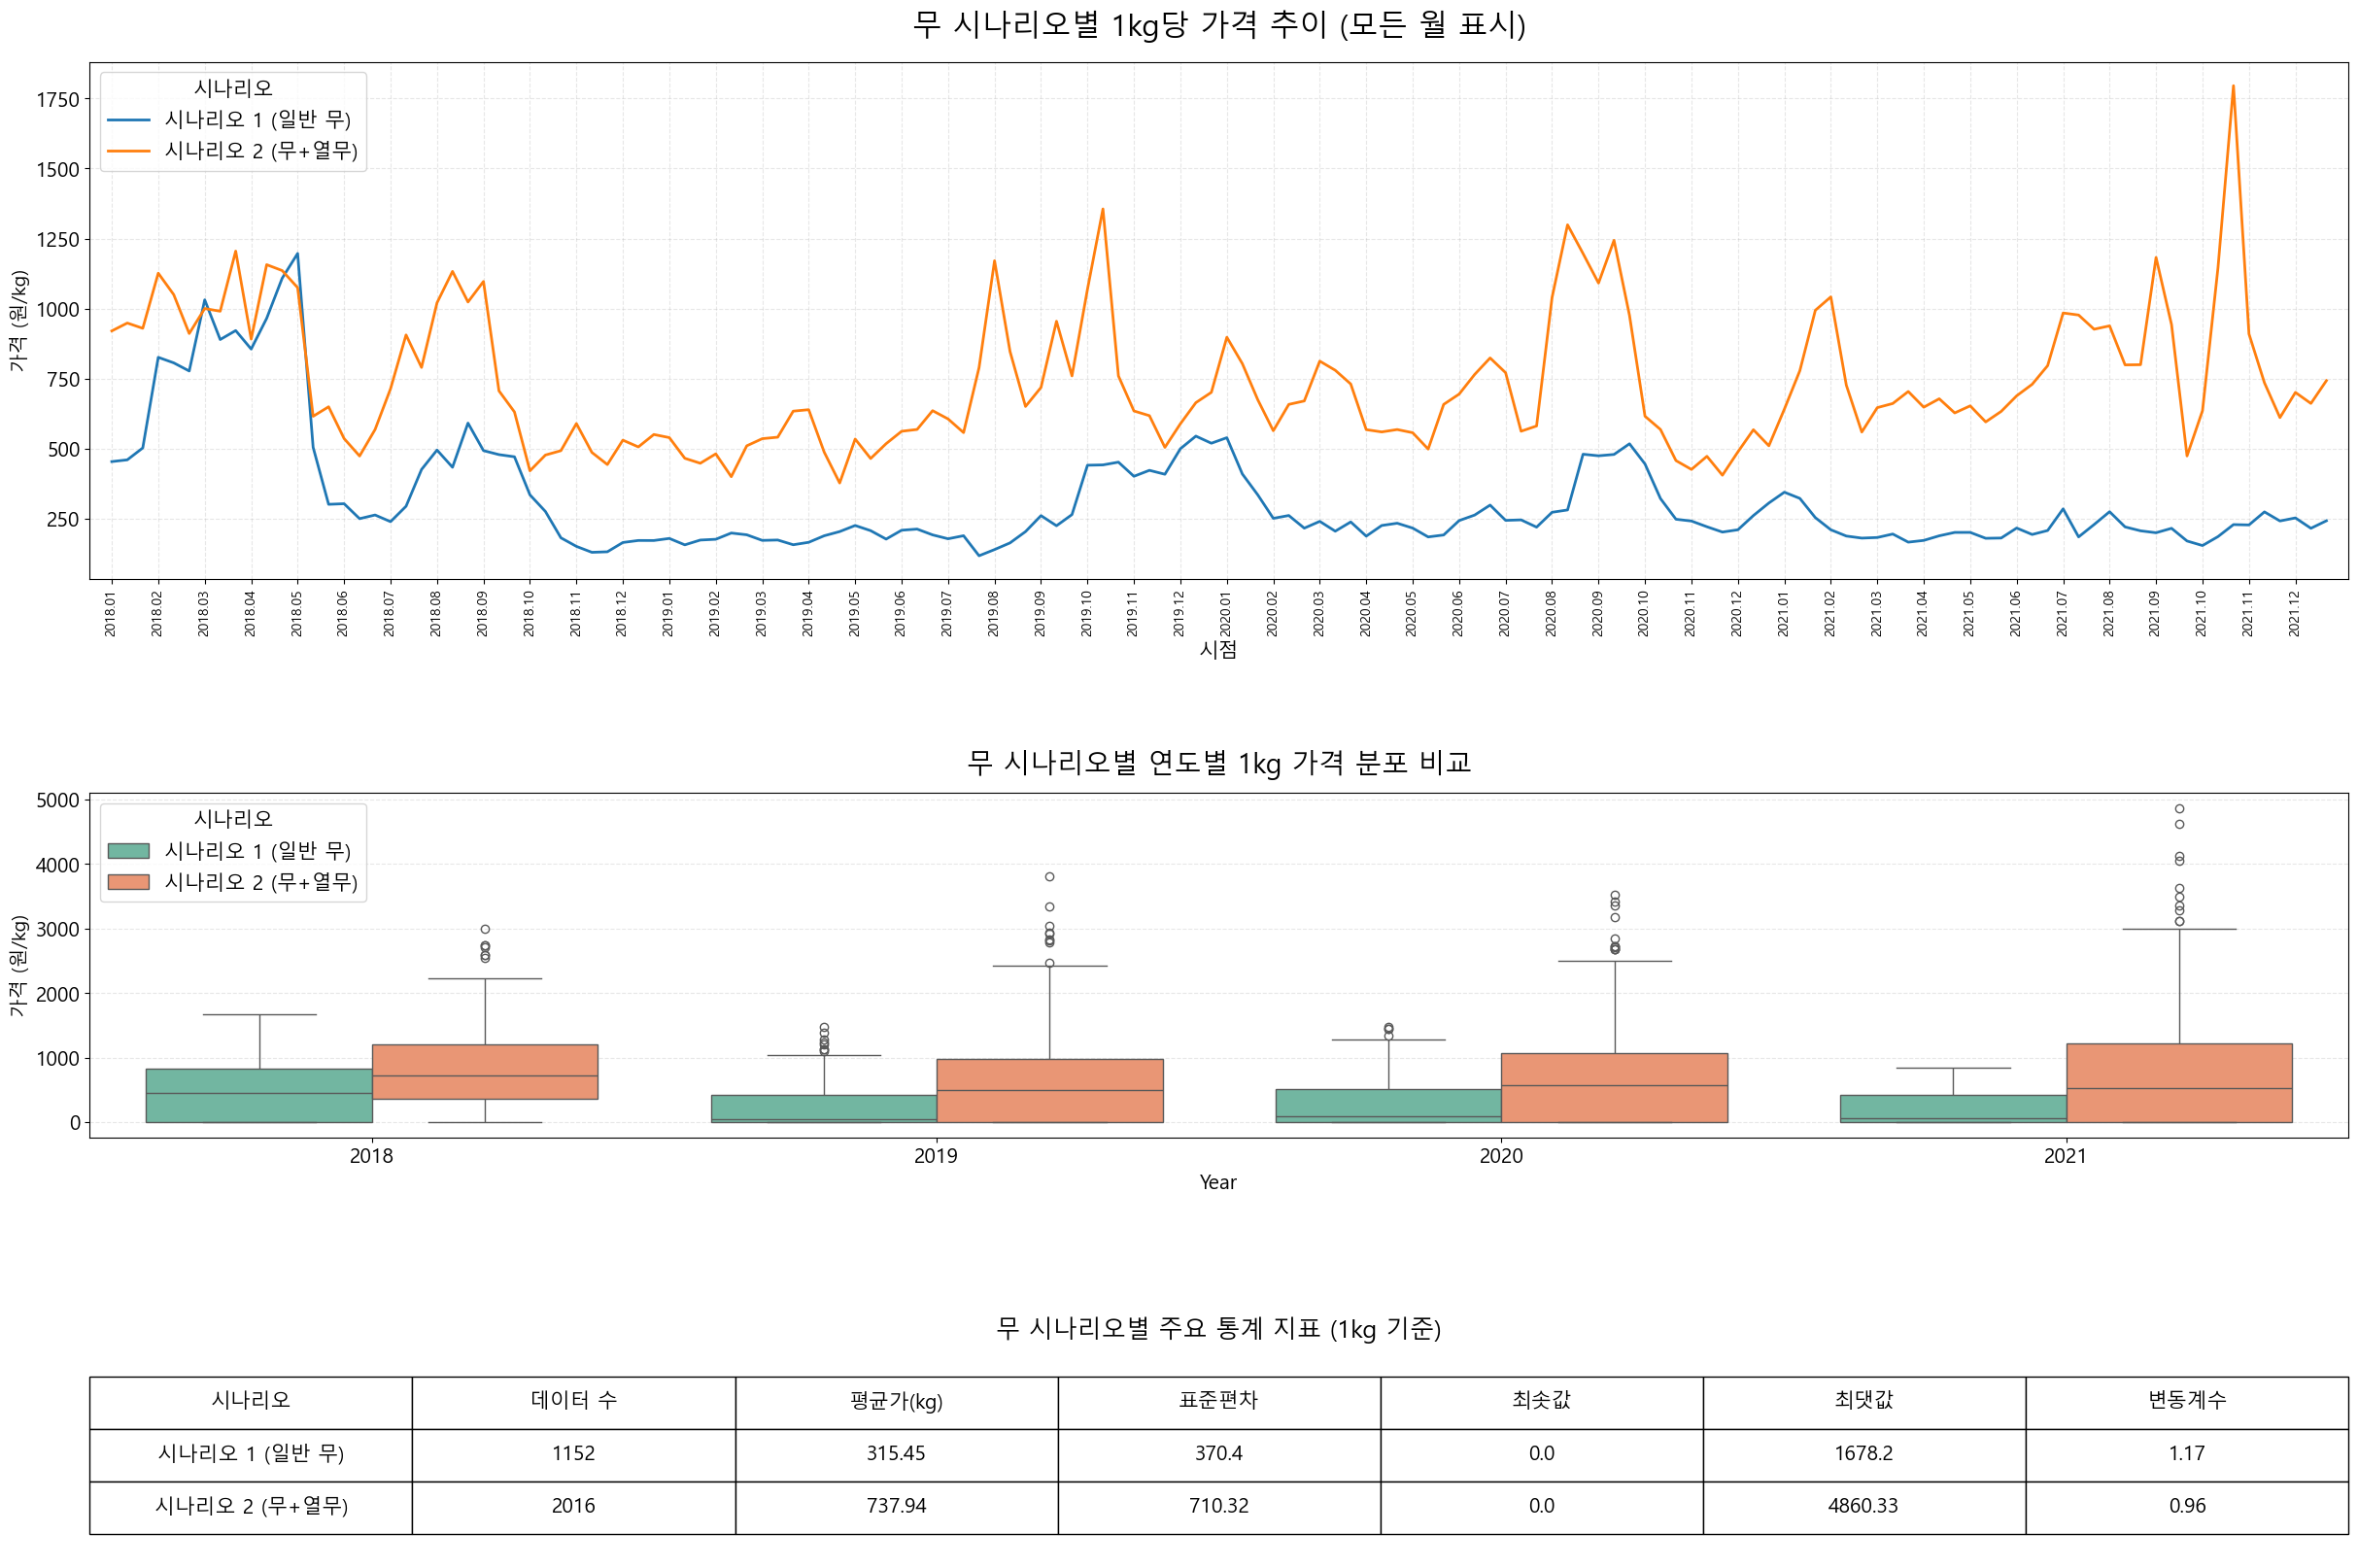

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. kg당 가격 환산 함수 정의
def convert_to_kg_price(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 단위 보정
df_radish = df[df['품목명'] == '무'].copy()
df_radish['가격_kg'] = df_radish.apply(convert_to_kg_price, axis=1)

# 시나리오 1: 일반 무
s1_radish = df_radish[df_radish['품종명'] == '무'].copy()
s1_radish['시나리오'] = '시나리오 1 (일반 무)'

# 시나리오 2: 무 + 열무
s2_radish = df_radish[df_radish['품종명'].isin(['무', '열무'])].copy()
s2_radish['시나리오'] = '시나리오 2 (무+열무)'

combined_radish = pd.concat([s1_radish, s2_radish])
combined_radish['YearMonth'] = combined_radish['시점'].str[:4] + "." + combined_radish['시점'].str[4:6]
combined_radish['Year'] = combined_radish['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장 포맷)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_radish, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
axes[0].set_title('무 시나리오별 1kg당 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_radish[combined_radish['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_radish, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='Set2')
axes[1].set_title('무 시나리오별 연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_radish = combined_radish.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_radish['변동계수'] = (summary_radish['std'] / summary_radish['mean']).round(4)
summary_radish.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_radish.round(2).values, 
                      colLabels=summary_radish.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4)
axes[2].set_title('무 시나리오별 주요 통계 지표 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

무는 변동계수 매우 큼

- 키로상자 단위 상이
- 열무가 더 비쌈

### 7. 상추
S1: 청(target)
S2: 청(target),적(유효비율 높은)

In [36]:
df[(df['품목명'] == '상추') & (df['품종명']=='청')]['거래단위'].unique()

array(['100 g'], dtype=object)

In [37]:
df[(df['품목명'] == '상추') & (df['품종명']=='적')]['거래단위'].unique()

array(['100 g'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\215463003.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_lettuce, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)


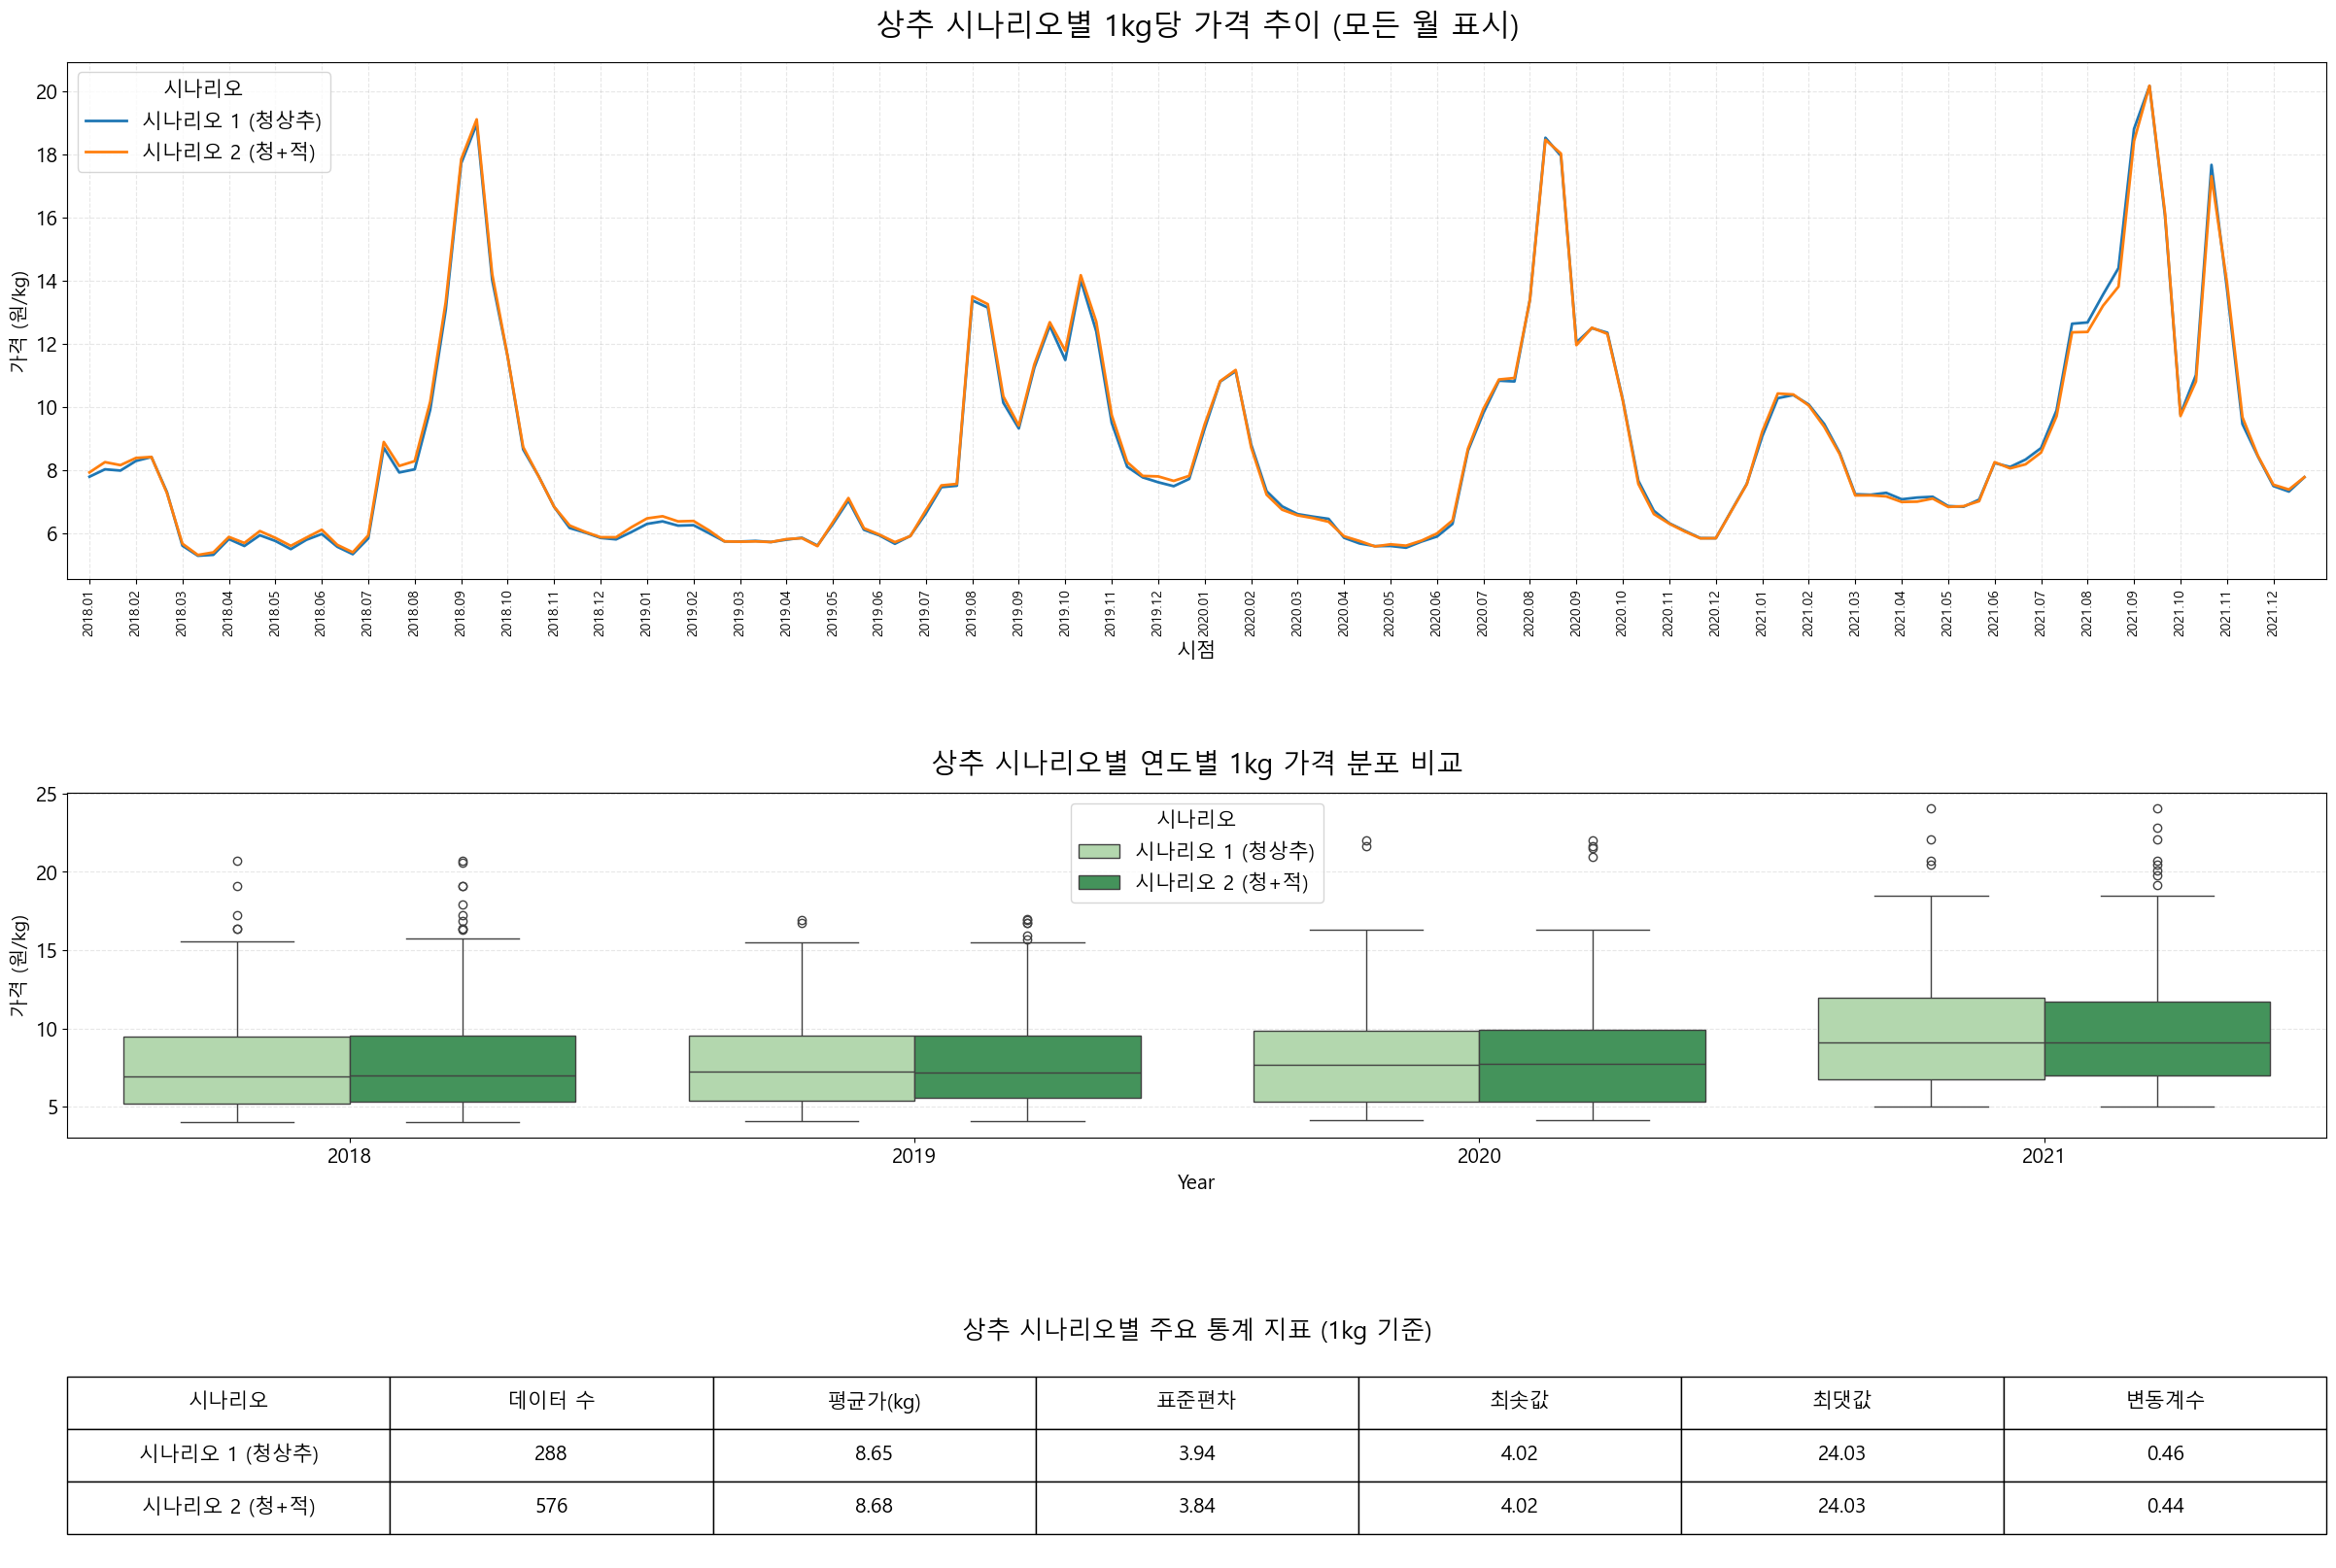

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. kg당 가격 환산 함수
def convert_to_kg_lettuce(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 단위 보정
df_lettuce = df[df['품목명'] == '상추'].copy()
df_lettuce['가격_kg'] = df_lettuce.apply(convert_to_kg_lettuce, axis=1)

# 시나리오 1: 청상추만
s1_lettuce = df_lettuce[df_lettuce['품종명'] == '청'].copy()
s1_lettuce['시나리오'] = '시나리오 1 (청상추)'

# 시나리오 2: 청상추 + 적상추
s2_lettuce = df_lettuce[df_lettuce['품종명'].isin(['청', '적'])].copy()
s2_lettuce['시나리오'] = '시나리오 2 (청+적)'

combined_lettuce = pd.concat([s1_lettuce, s2_lettuce])
combined_lettuce['YearMonth'] = combined_lettuce['시점'].str[:4] + "." + combined_lettuce['시점'].str[4:6]
combined_lettuce['Year'] = combined_lettuce['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장 포맷)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_lettuce, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2)
axes[0].set_title('상추 시나리오별 1kg당 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_lettuce[combined_lettuce['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_lettuce, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='Greens')
axes[1].set_title('상추 시나리오별 연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_lettuce = combined_lettuce.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_lettuce['변동계수'] = (summary_lettuce['std'] / summary_lettuce['mean']).round(4)
summary_lettuce.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_lettuce.round(2).values, 
                      colLabels=summary_lettuce.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4)
axes[2].set_title('상추 시나리오별 주요 통계 지표 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

- 여름에 매년 상승(2~3배)
- 청, 적 동조화 -> 데이터 두개 섞어도 될 듯

### 8. 배추
S1: 배추(target)
S2: 배추(target), 알배기 배추(유효비율 높은)
S3: 배추(target), 알배기 배추, 쌈배추(유효비율 높은)

In [41]:
df[(df['품목명'] == '배추') & (df['품종명']=='배추')]['거래단위'].unique()

array(['10키로망대'], dtype=object)

In [43]:
df[(df['품목명'] == '배추') & (df['품종명']=='알배기배추')]['거래단위'].unique()

array(['8키로상자'], dtype=object)

In [44]:
df[(df['품목명'] == '배추') & (df['품종명']=='쌈배추')]['거래단위'].unique()

array(['1키로상자', '8키로상자'], dtype=object)

단위 1kg당으로

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\1847113187.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_cab, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)


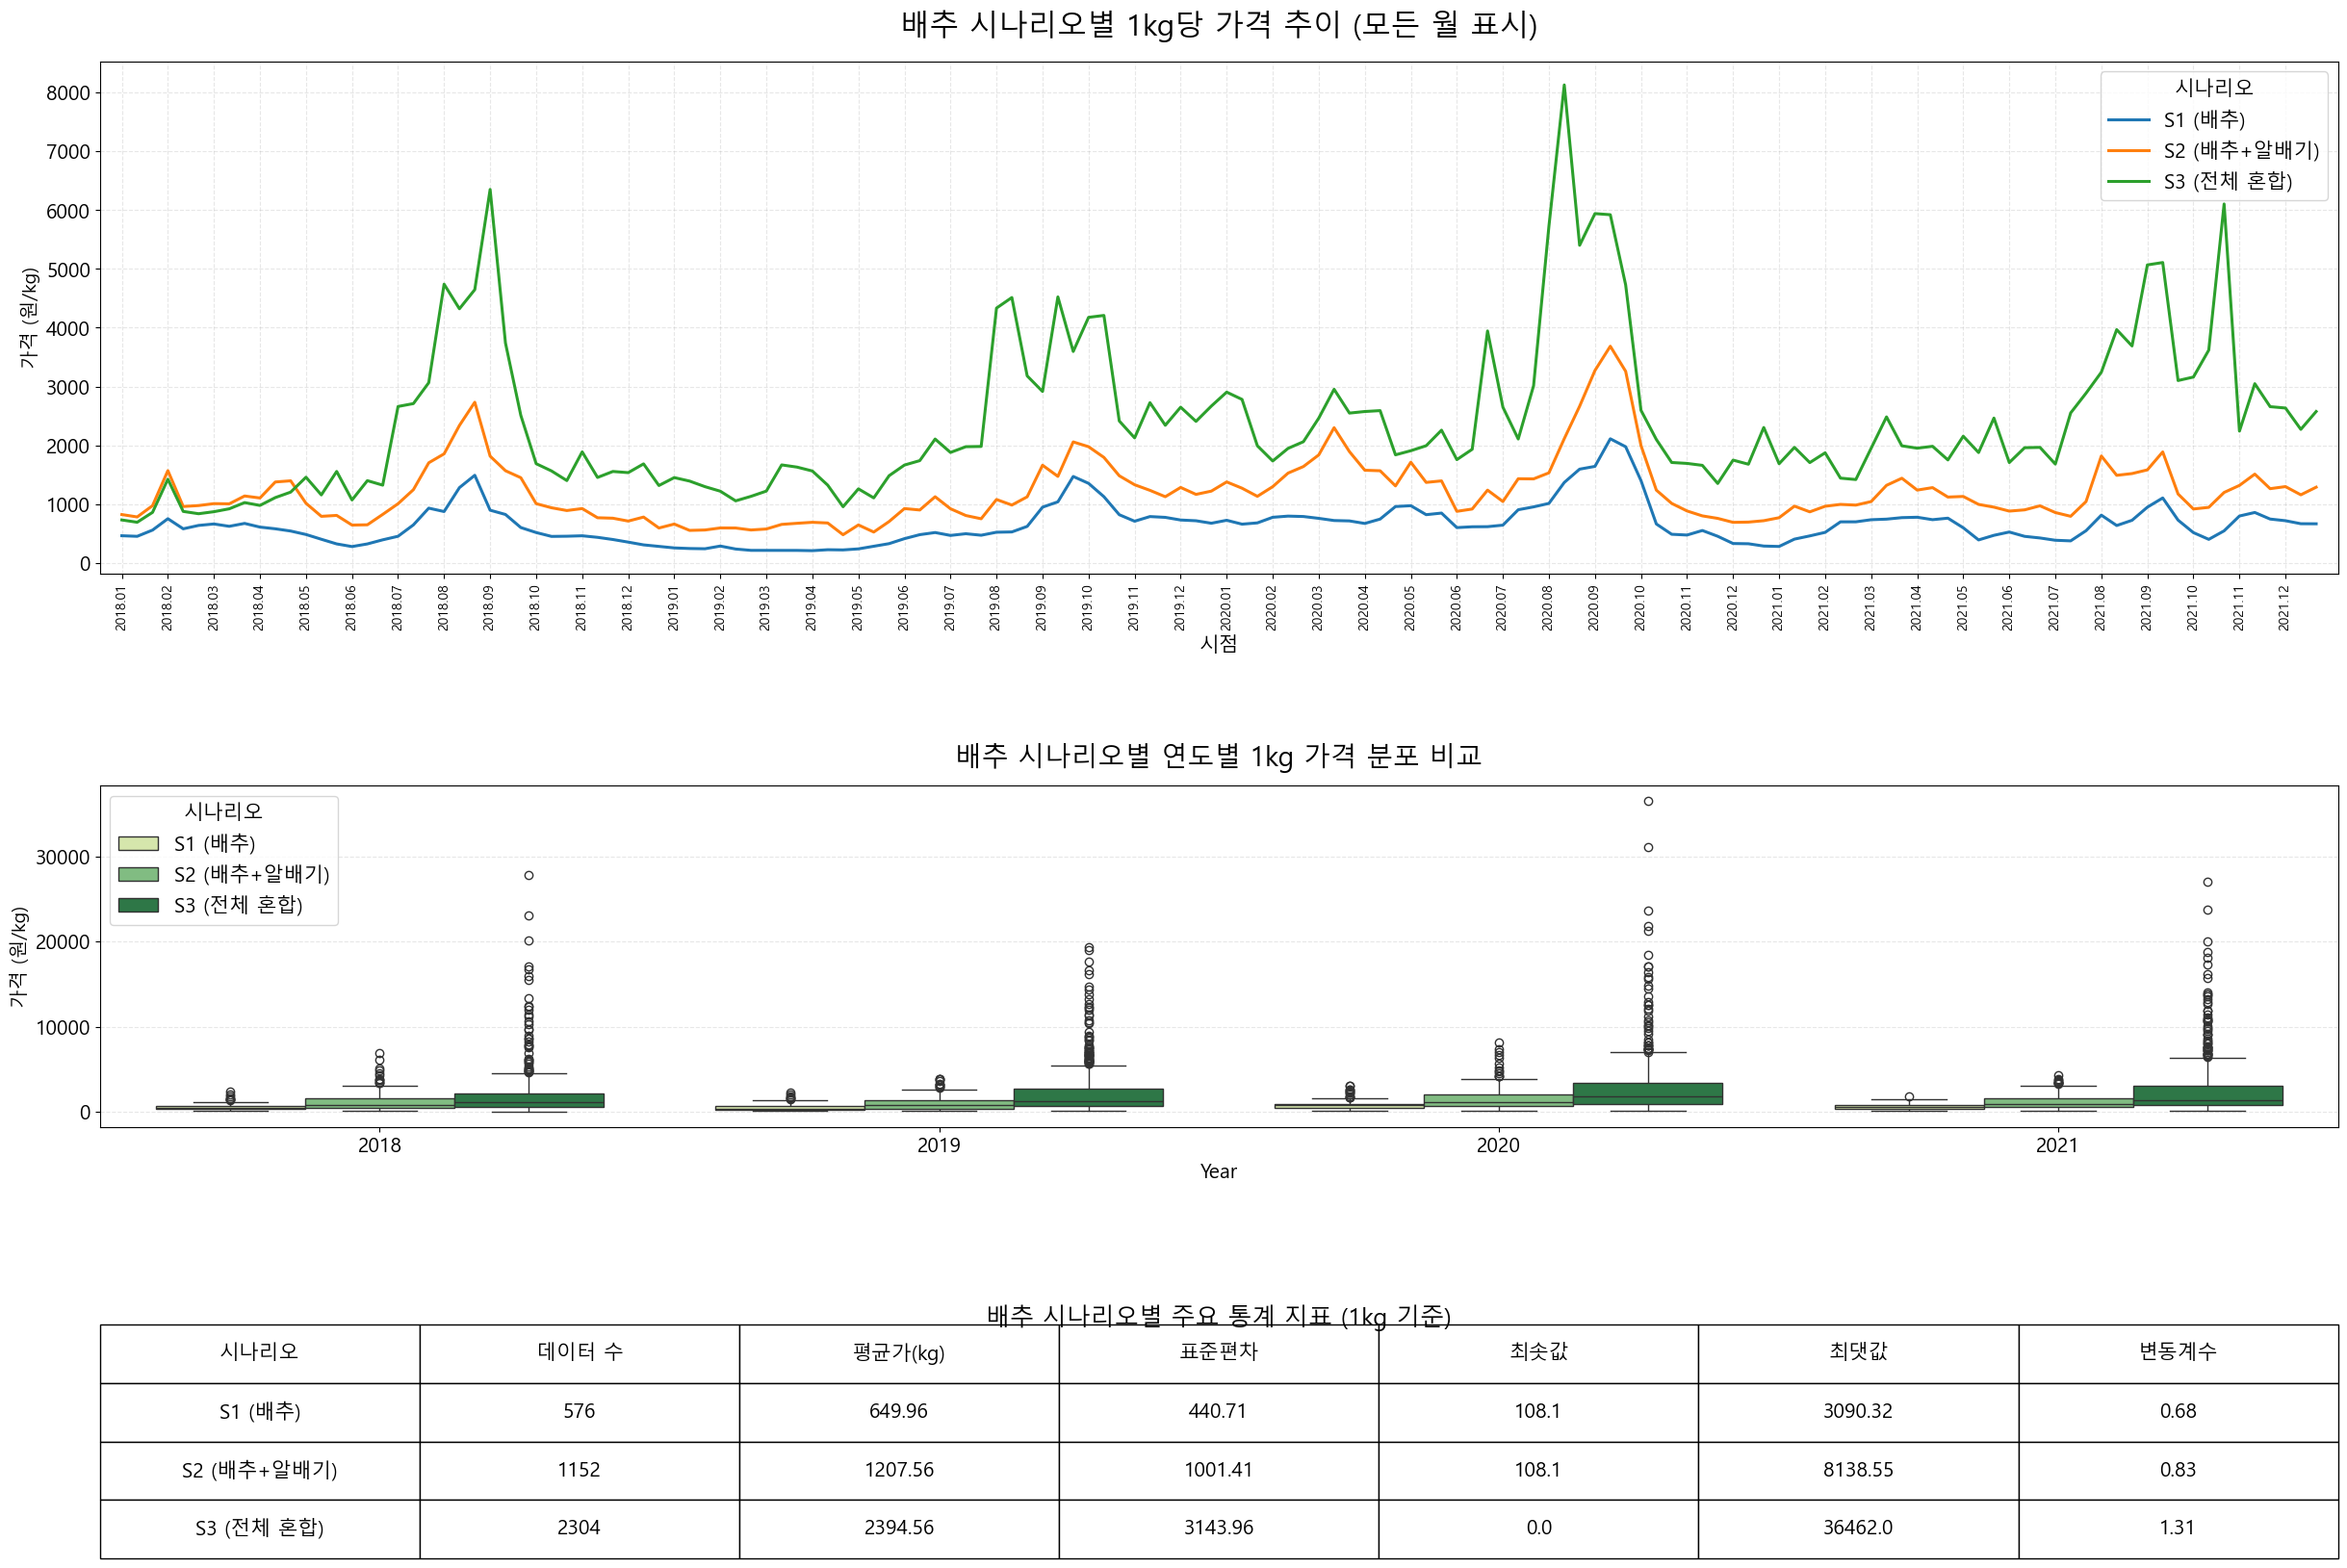

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. kg당 가격 환산 함수
def convert_to_kg_cabbage(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 단위 보정
df_cabbage = df[df['품목명'] == '배추'].copy()
df_cabbage['가격_kg'] = df_cabbage.apply(convert_to_kg_cabbage, axis=1)

# 시나리오 설정
s1_cab = df_cabbage[df_cabbage['품종명'] == '배추'].copy()
s1_cab['시나리오'] = 'S1 (배추)'

s2_cab = df_cabbage[df_cabbage['품종명'].isin(['배추', '알배기배추'])].copy()
s2_cab['시나리오'] = 'S2 (배추+알배기)'

s3_cab = df_cabbage[df_cabbage['품종명'].isin(['배추', '알배기배추', '쌈배추'])].copy()
s3_cab['시나리오'] = 'S3 (전체 혼합)'

combined_cab = pd.concat([s1_cab, s2_cab, s3_cab])
combined_cab['YearMonth'] = combined_cab['시점'].str[:4] + "." + combined_cab['시점'].str[4:6]
combined_cab['Year'] = combined_cab['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장 포맷)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_cab, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)
axes[0].set_title('배추 시나리오별 1kg당 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_cab[combined_cab['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_cab, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='YlGn')
axes[1].set_title('배추 시나리오별 연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_cab = combined_cab.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_cab['변동계수'] = (summary_cab['std'] / summary_cab['mean']).round(4)
summary_cab.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_cab.round(2).values, 
                      colLabels=summary_cab.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4.5)
axes[2].set_title('배추 시나리오별 주요 통계 지표 (1kg 기준)', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

- 급격한 단가 차이 (배추 < 알배기 < 쌈)
- 계절성(김장철)

### 9. 양파
S1: 양파(target)
S2: 양파(target), 자주양파(유효비율 높음)

In [46]:
df[(df['품목명'] == '양파') & (df['품종명']=='양파')]['거래단위'].unique()

array(['1키로', '15키로', '20키로', '12키로', '10키로'], dtype=object)

In [47]:
df[(df['품목명'] == '양파') & (df['품종명']=='자주양파')]['거래단위'].unique()

array(['12키로', '1키로', '20키로'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\2718942093.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_onion, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)


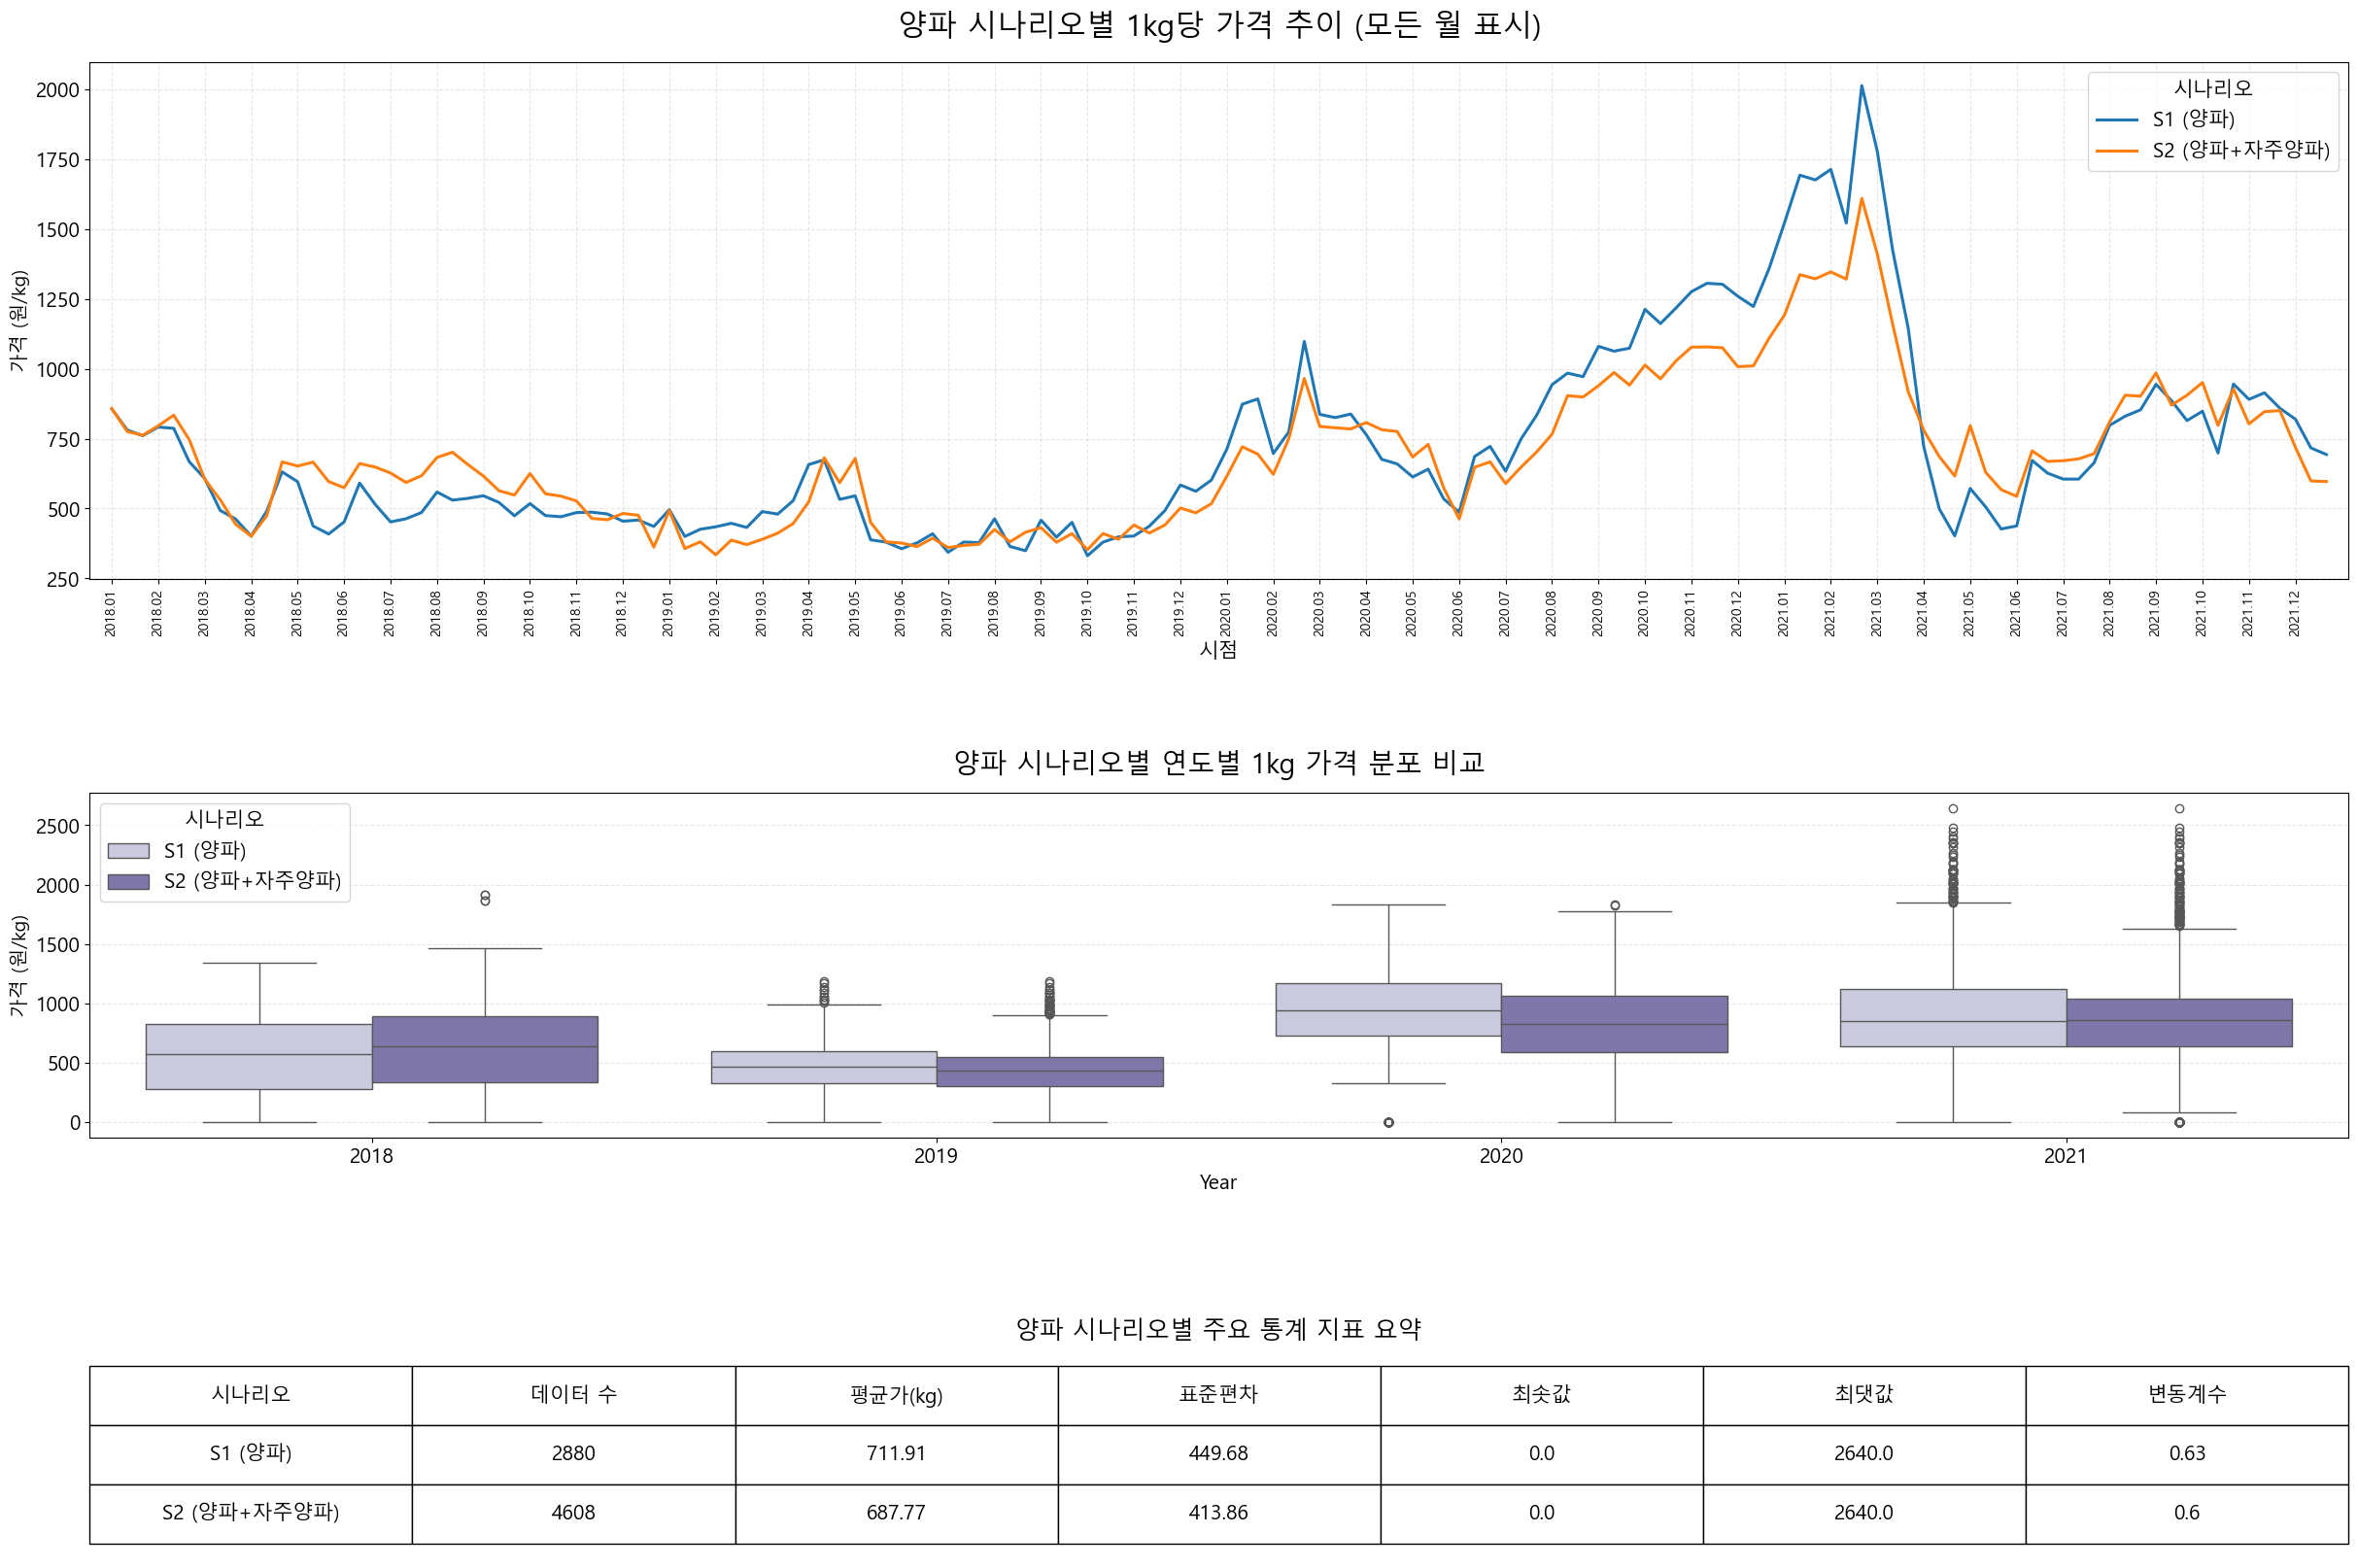

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. kg당 가격 환산 함수
def convert_to_kg_onion(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 단위 보정
df_onion = df[df['품목명'] == '양파'].copy()
df_onion['가격_kg'] = df_onion.apply(convert_to_kg_onion, axis=1)

# 시나리오 설정
s1_onion = df_onion[df_onion['품종명'] == '양파'].copy()
s1_onion['시나리오'] = 'S1 (양파)'

s2_onion = df_onion[df_onion['품종명'].isin(['양파', '자주양파'])].copy()
s2_onion['시나리오'] = 'S2 (양파+자주양파)'

combined_onion = pd.concat([s1_onion, s2_onion])
combined_onion['YearMonth'] = combined_onion['시점'].str[:4] + "." + combined_onion['시점'].str[4:6]
combined_onion['Year'] = combined_onion['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장 포맷)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_onion, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)
axes[0].set_title('양파 시나리오별 1kg당 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_onion[combined_onion['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_onion, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='Purples')
axes[1].set_title('양파 시나리오별 연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_onion = combined_onion.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_onion['변동계수'] = (summary_onion['std'] / summary_onion['mean']).round(4)
summary_onion.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_onion.round(2).values, 
                      colLabels=summary_onion.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4.5)
axes[2].set_title('양파 시나리오별 주요 통계 지표 요약', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

- 2021년도 상반기 치솟음

### 10. 대파
S1: 대파(일반)(target)
S2: 대파(일반)(target), 깐쪽파, 쪽파

In [49]:
df[(df['품목명'] == '대파') & (df['품종명']=='대파(일반)')]['거래단위'].unique()

array(['1키로단', '10키로묶음'], dtype=object)

In [50]:
df[(df['품목명'] == '대파') & (df['품종명']=='깐쪽파')]['거래단위'].unique()

array(['10키로상자'], dtype=object)

In [51]:
df[(df['품목명'] == '대파') & (df['품종명']=='쪽파')]['거래단위'].unique()

array(['10키로상자'], dtype=object)

C:\Users\LG\AppData\Local\Temp\ipykernel_34720\3772023177.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=combined_green, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)


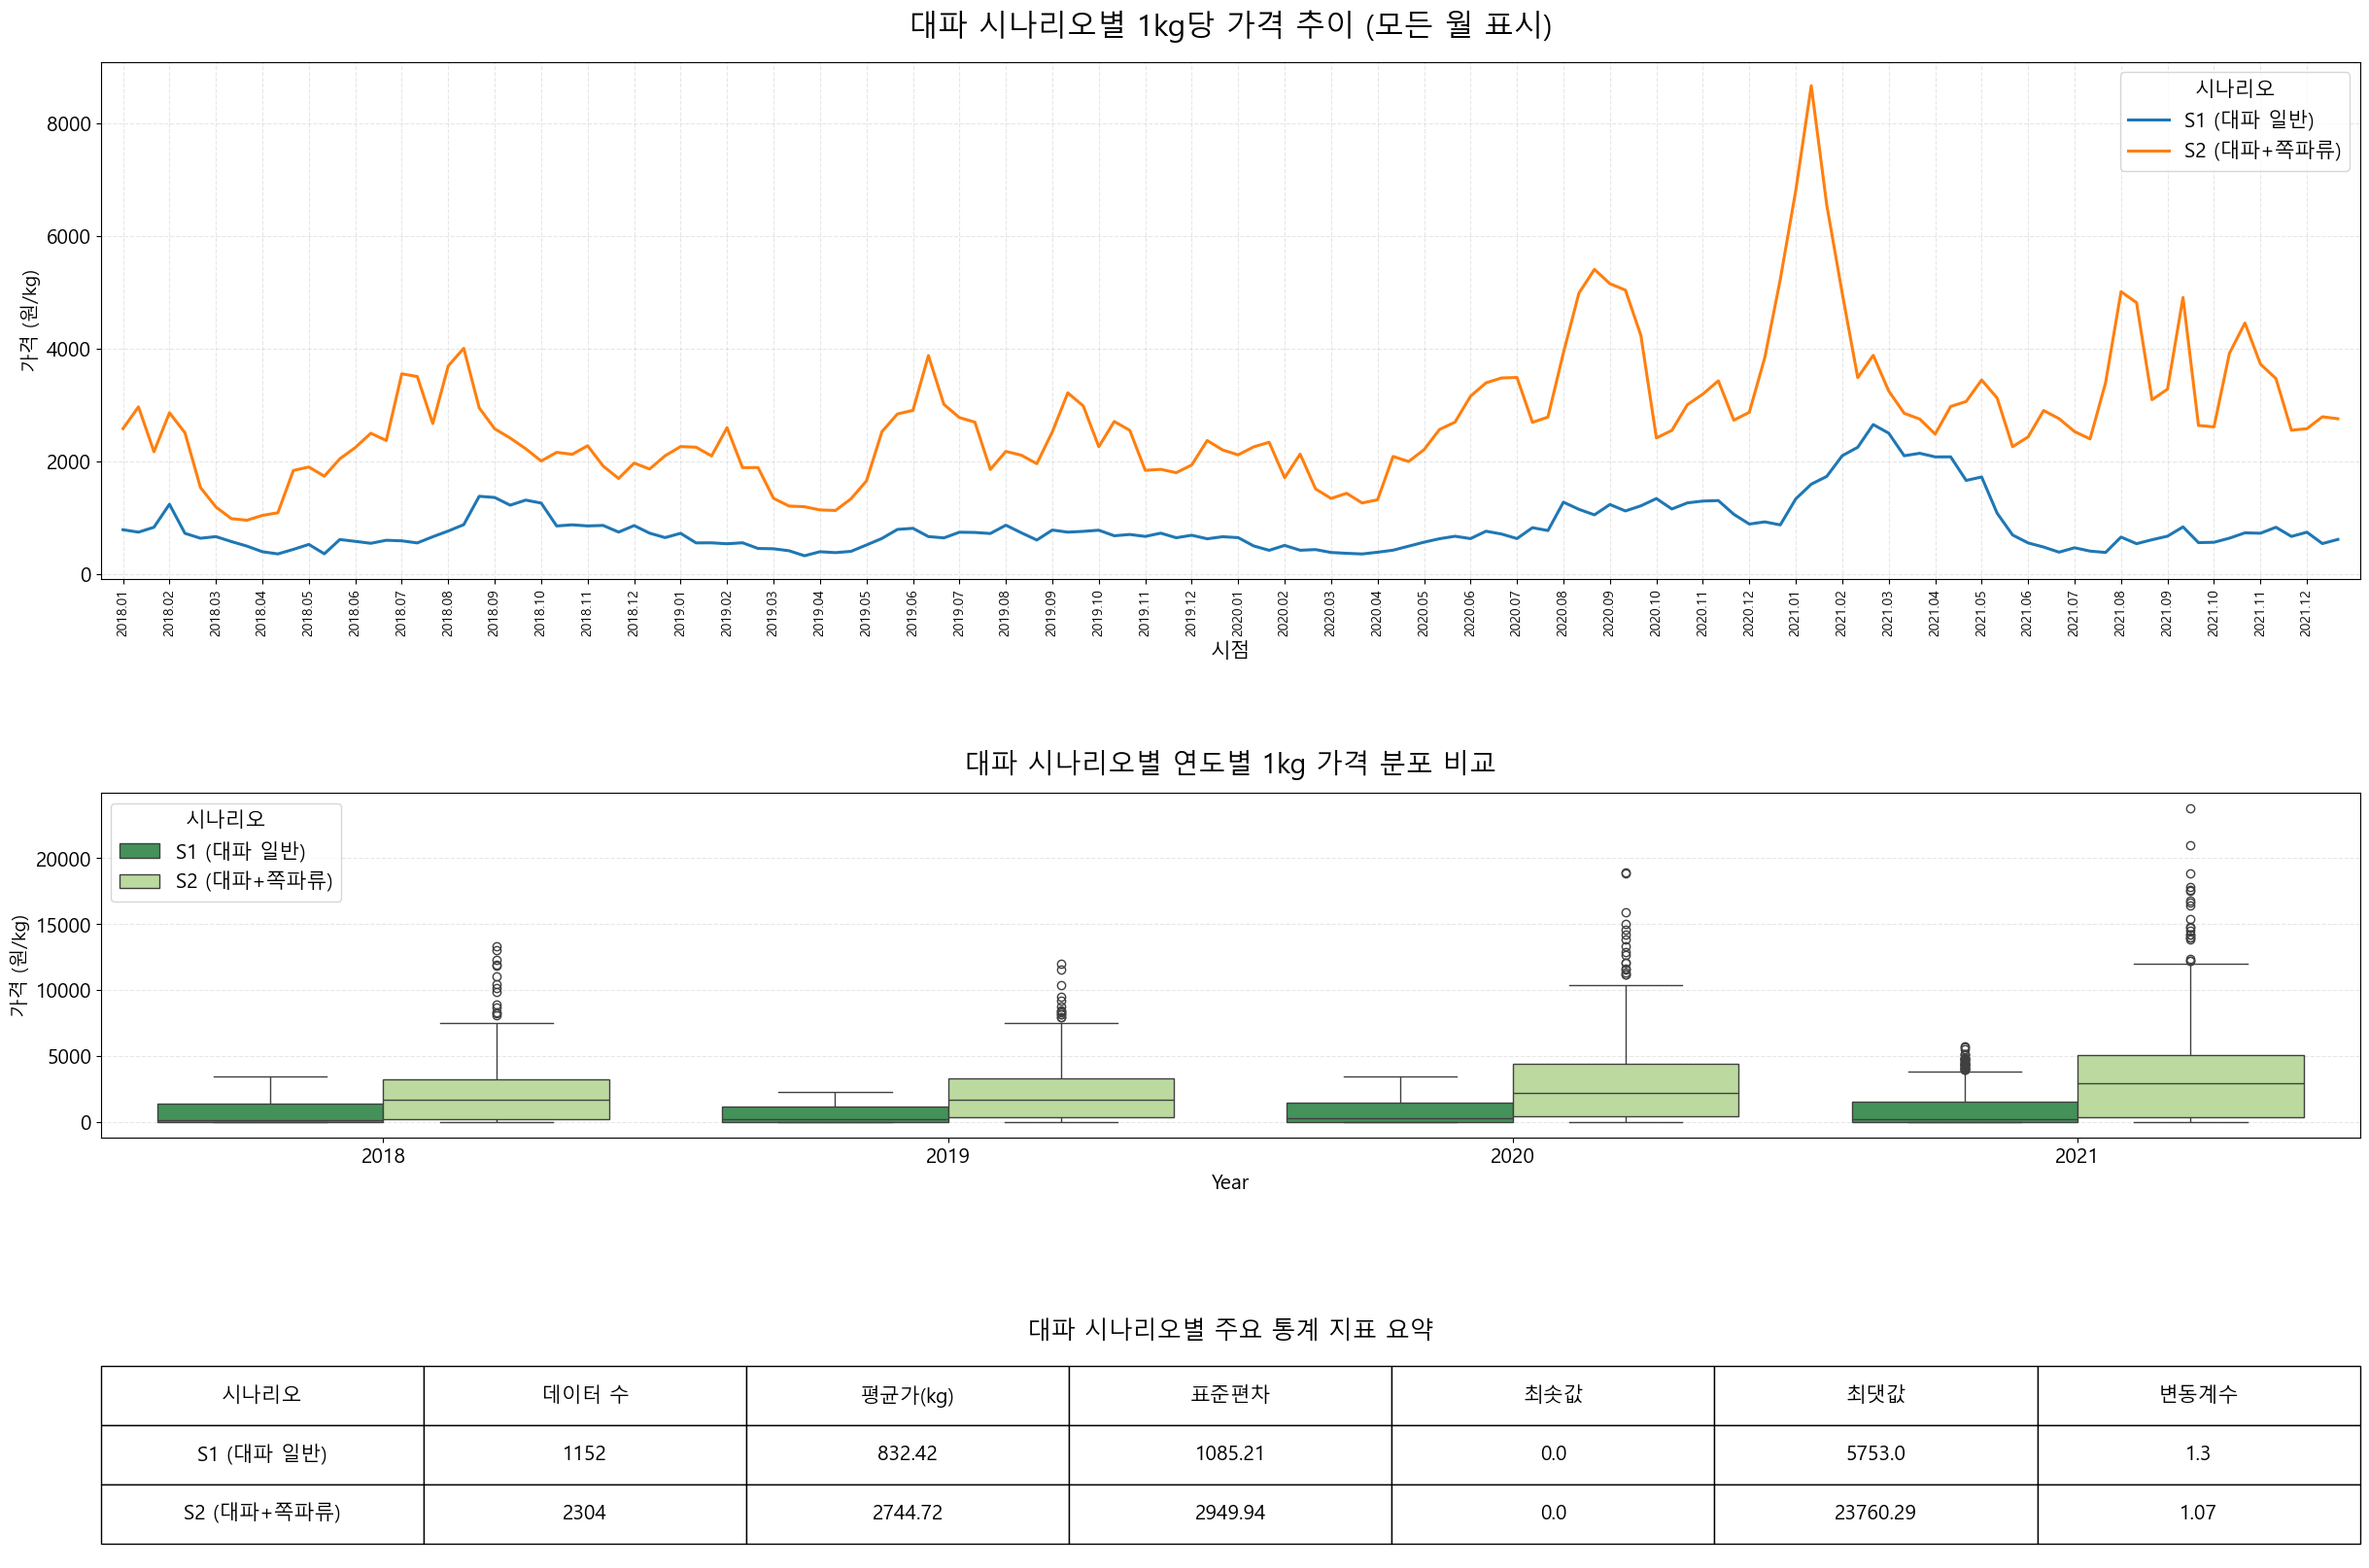

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. kg당 가격 환산 함수
def convert_to_kg_green_onion(row):
    unit = str(row['거래단위'])
    price = row['평균가격(원)']
    if price == 0: return 0
    num_match = re.search(r'(\d+\.?\d*)', unit)
    weight = float(num_match.group(1)) if num_match else 1.0
    return price / weight

# 2. 데이터 필터링 및 단위 보정
df_green = df[df['품목명'] == '대파'].copy()
df_green['가격_kg'] = df_green.apply(convert_to_kg_green_onion, axis=1)

# 시나리오 설정
s1_green = df_green[df_green['품종명'] == '대파(일반)'].copy()
s1_green['시나리오'] = 'S1 (대파 일반)'

s2_green = df_green[df_green['품종명'].isin(['대파(일반)', '깐쪽파', '쪽파'])].copy()
s2_green['시나리오'] = 'S2 (대파+쪽파류)'

combined_green = pd.concat([s1_green, s2_green])
combined_green['YearMonth'] = combined_green['시점'].str[:4] + "." + combined_green['시점'].str[4:6]
combined_green['Year'] = combined_green['시점'].str[:4]

# 3. 시각화 (가로 30인치 확장 포맷)
fig, axes = plt.subplots(3, 1, figsize=(30, 20), gridspec_kw={'height_ratios': [1.5, 1, 0.6]})

# --- [EDA 1] 시계열 추이 (모든 월 노출) ---
sns.lineplot(data=combined_green, x='시점', y='가격_kg', hue='시나리오', ax=axes[0], ci=None, linewidth=2.2)
axes[0].set_title('대파 시나리오별 1kg당 가격 추이 (모든 월 표시)', fontsize=22, pad=20)
axes[0].set_ylabel('가격 (원/kg)', fontsize=14)

# x축 설정: 모든 '상순' 데이터를 리스트업하여 90도 회전
all_ticks = combined_green[combined_green['시점'].str.contains("상순")].drop_duplicates('YearMonth').sort_values('시점')
axes[0].set_xticks(all_ticks['시점'])
axes[0].set_xticklabels(all_ticks['YearMonth'], rotation=90, fontsize=10)
axes[0].grid(True, which='both', linestyle='--', alpha=0.3)
axes[0].margins(x=0.01)

# --- [EDA 2] 연도별 가격 분포 비교 (Boxplot) ---
sns.boxplot(data=combined_green, x='Year', y='가격_kg', hue='시나리오', ax=axes[1], palette='YlGn_r')
axes[1].set_title('대파 시나리오별 연도별 1kg 가격 분포 비교', fontsize=20, pad=15)
axes[1].set_ylabel('가격 (원/kg)', fontsize=14)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.3)

# --- [EDA 3] 통계 요약 테이블 ---
axes[2].axis('off')
summary_green = combined_green.groupby('시나리오')['가격_kg'].agg(['count', 'mean', 'std', 'min', 'max']).reset_index()
summary_green['변동계수'] = (summary_green['std'] / summary_green['mean']).round(4)
summary_green.columns = ['시나리오', '데이터 수', '평균가(kg)', '표준편차', '최솟값', '최댓값', '변동계수']

table = axes[2].table(cellText=summary_green.round(2).values, 
                      colLabels=summary_green.columns, 
                      loc='center', 
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1, 4.5)
axes[2].set_title('대파 시나리오별 주요 통계 지표 요약', fontsize=18, pad=10)

plt.subplots_adjust(hspace=0.6)
plt.show()

- 쪽파 >>> 대파
- 일반 대파의 상대적 가격 안정성

 ## 통합 데이터셋 구축 로직

In [30]:
import pandas as pd
import numpy as np
import re

# 1. 시나리오 정의 (Target 및 유효비율 기반)
target_scenarios = {
    '건고추': ['화건'],
    '사과': ['후지'],
    '감자': ['수미'],
    '배': ['신고'],
    '깐마늘': ['깐마늘(국산)'],
    '무': ['무'],
    '상추': ['청', '적'], # Target은 '청'이나 데이터 확보를 위해 '적' 포함
    '배추': ['배추'],
    '양파': ['양파'],
    '대파': ['대파(일반)']
}

def build_final_dataset_v2(df):
    final_list = []
    
    def get_kg_price(row):
        unit = str(row['거래단위'])
        price = row['평균가격(원)']
        if price <= 0: return np.nan
        num = re.search(r'(\d+\.?\d*)', unit)
        weight = float(num.group(1)) if num else 1.0
        return price / weight

    for item, varieties in target_scenarios.items():
        # 필터링
        temp = df[(df['품목명'] == item) & (df['품종명'].isin(varieties))].copy()
        temp['가격_kg'] = temp.apply(get_kg_price, axis=1)
        
        # [핵심] 중복 제거: 같은 날짜(시점)에 여러 데이터가 있다면 평균값으로 통합
        temp = temp.groupby(['시점', '품목명'])['가격_kg'].mean().reset_index()
        
        # 시계열 순서 정렬
        temp = temp.sort_values('시점')
        
        # 선형 보간 (결측치 채우기)
        temp['가격_kg'] = temp['가격_kg'].interpolate(method='linear', limit_direction='both')
        
        final_list.append(temp)
    
    # 데이터 병합
    combined = pd.concat(final_list)
    
    # 이제 중복이 없으므로 pivot 가능 (안전하게 pivot_table 사용 권장)
    final_pivot = combined.pivot_table(index='시점', columns='품목명', values='가격_kg', aggfunc='mean')
    
    return final_pivot

# 실행
try:
    final_train_df = build_final_dataset_v2(df)
    print("✅ 통합 데이터셋")
    print(f"데이터 크기: {final_train_df.shape}")
    print(final_train_df.head())
except Exception as e:
    print(f"❌ 에러 발생: {e}")

✅ 통합 데이터셋
데이터 크기: (144, 8)
품목명                건고추           대파           무        배          배추      사과  \
시점                                                                             
201801상순  18916.666667  1583.107143  453.364881  2291.80  462.528571  1765.3   
201801중순  18916.666667  1496.611111  459.565432  2303.90  452.736111  1759.6   
201801하순  18916.666667  1671.083333  502.140451  2353.25  558.463889  1794.9   
201802상순  18916.666667  2486.750000  825.729552  2336.95  752.419444  1804.0   
201802중순  18916.666667  1455.708333  805.929861  2391.25  580.650000  1873.8   

품목명           상추           양파  
시점                             
201801상순  7.9225  1070.782589  
201801중순  8.2475   975.847338  
201801하순  8.1525   951.087269  
201802상순  8.3800   989.773148  
201802중순  8.4125   983.700486  


In [32]:
# 1. 상단/하단 데이터를 합쳐서 데이터프레임 형태로 출력
# (주피터 노트북 환경이라면 마지막에 변수명만 적어도 표로 나옵니다)
display_df = pd.concat([final_train_df.head(10), final_train_df.tail(10)])

print("--- [최종 통합 데이터프레임: 상/하단 10행] ---")
display(display_df) # 주피터 환경용 출력 함수

# 2. 데이터가 잘 채워졌는지 요약 리포트 출력
print("\n" + "="*50)
print("🔍 데이터 정제 상태 리포트")
print("="*50)

report = pd.DataFrame({
    '결측치 수': final_train_df.isnull().sum(),
    '평균 가격(kg)': final_train_df.mean().round(1),
    '최저 가격(kg)': final_train_df.min().round(1),
    '최고 가격(kg)': final_train_df.max().round(1)
})

display(report)

--- [최종 통합 데이터프레임: 상/하단 10행] ---


품목명,건고추,대파,무,배,배추,사과,상추,양파
시점,,,,,,,,
201801상순,18916.666667,1583.107143,453.364881,2291.80,462.528571,1765.300000,7.9225,1070.782589
201801중순,18916.666667,1496.611111,459.565432,2303.90,452.736111,1759.600000,8.2475,975.847338
201801하순,18916.666667,1671.083333,502.140451,2353.25,558.463889,1794.900000,8.1525,951.087269
201802상순,18916.666667,2486.750000,825.729552,2336.95,752.419444,1804.000000,8.3800,989.773148
201802중순,18916.666667,1455.708333,805.929861,2391.25,580.650000,1873.800000,8.4125,983.700486
201802하순,18611.100000,1281.178571,776.900198,2376.90,637.960714,1838.150000,7.2700,834.596280
201803상순,18027.766667,1338.750000,1031.016821,2330.00,662.838889,1827.500000,5.6625,759.366088
201803중순,18416.666667,1163.000000,889.221441,2326.60,623.046875,1805.750000,5.3050,616.560807
201803하순,18416.666667,1002.475000,921.287569,2342.65,672.295000,1817.750000,5.3875,577.792477



🔍 데이터 정제 상태 리포트


,결측치 수,평균 가격(kg),최저 가격(kg),최고 가격(kg)
품목명,,,,
건고추,0,18985.4,12350.0,29079.6
대파,0,1664.8,659.8,5313.5
무,0,556.0,234.0,1196.7
배,0,3116.8,2291.8,5051.4
배추,0,650.0,208.8,2111.3
사과,0,2130.5,1280.0,3028.9
상추,0,8.7,5.3,20.2
양파,0,803.3,343.6,2013.3


## 품목별 상관관계 (heatmap)

C:\Users\LG\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128194 (\N{OPEN FILE FOLDER}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


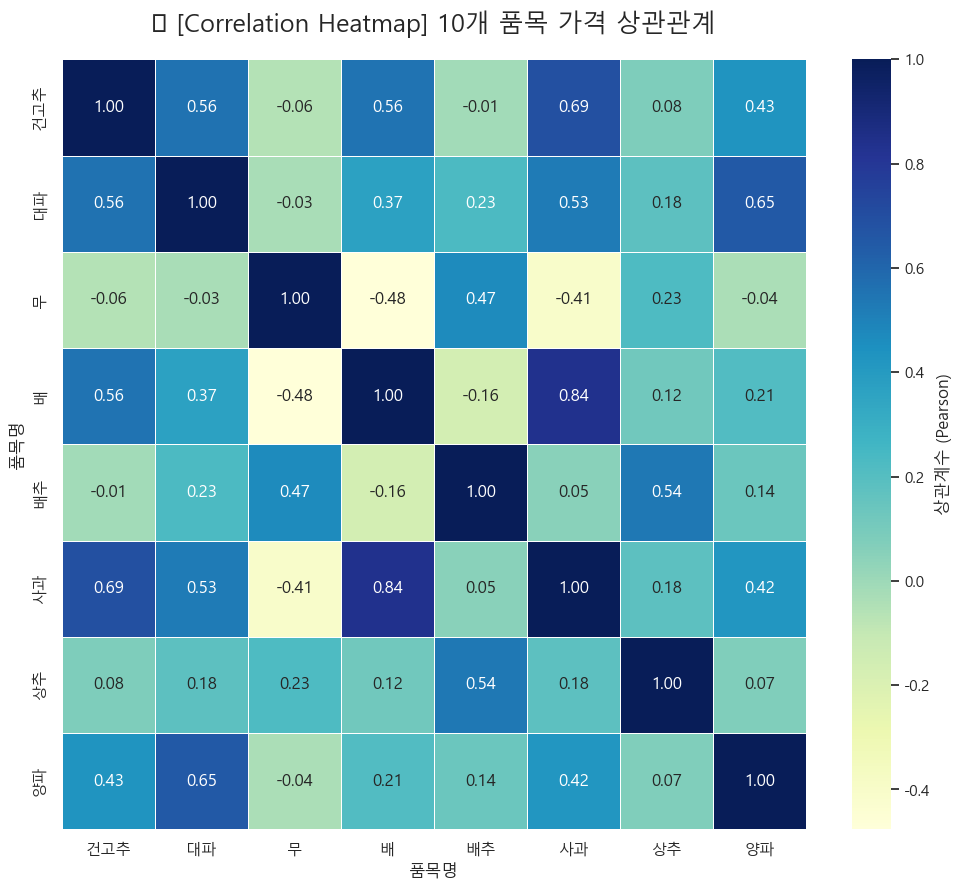

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 설정 (환경에 맞게 자동 선택)
if platform.system() == 'Darwin': # 맥
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows': # 윈도우
    plt.rc('font', family='Malgun Gothic')
else: # 리눅스 (코랩 등)
    plt.rc('font', family='NanumBarunGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 2. 상관계수 계산
corr_matrix = final_train_df.corr()

# 3. 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.set(font="Malgun Gothic", # Seaborn용 폰트 별도 설정 (윈도우 기준, 맥은 AppleGothic)
        rc={"axes.unicode_minus":False},
        style='white')

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=0.5,
            cbar=True,
            cbar_kws={"label": "상관계수 (Pearson)"})

plt.title('📂 [Correlation Heatmap] 10개 품목 가격 상관관계', fontsize=18, pad=20)
plt.show()

In [42]:
# 1. 시차 데이터(Lag) 생성 함수
def create_lag_features(df, lags=[1, 2]):
    lagged_df = df.copy()
    
    for col in df.columns:
        for lag in lags:
            # shift(1)은 데이터를 한 칸 아래로 미는 것 (즉, 이전 시점의 가격)
            lagged_df[f'{col}_lag{lag}'] = df[col].shift(lag)
            
    # 시차 데이터를 만들면 맨 앞줄은 이전 데이터가 없어 NaN이 생기므로 제거
    return lagged_df.dropna()

# 2. 특징 추출 실행 (1단계 전, 2단계 전 가격 추가)
model_ready_df = create_lag_features(final_train_df, lags=[1, 2])

# 3. 결과 확인
print("✨ 모델 학습용 데이터셋 준비 완료!")
print(f"기존 컬럼 수: {len(final_train_df.columns)} -> 생성 후 컬럼 수: {len(model_ready_df.columns)}")
display(model_ready_df.head())

✨ 모델 학습용 데이터셋 준비 완료!
기존 컬럼 수: 8 -> 생성 후 컬럼 수: 24


품목명,건고추,대파,무,배,배추,사과,상추,양파,건고추_lag1,건고추_lag2,...,배_lag1,배_lag2,배추_lag1,배추_lag2,사과_lag1,사과_lag2,상추_lag1,상추_lag2,양파_lag1,양파_lag2
시점,,,,,,,,,,,,,,,,,,,,,
201801하순,18916.666667,1671.083333,502.140451,2353.25,558.463889,1794.90,8.1525,951.087269,18916.666667,18916.666667,...,2303.90,2291.80,452.736111,462.528571,1759.60,1765.3,8.2475,7.9225,975.847338,1070.782589
201802상순,18916.666667,2486.750000,825.729552,2336.95,752.419444,1804.00,8.3800,989.773148,18916.666667,18916.666667,...,2353.25,2303.90,558.463889,452.736111,1794.90,1759.6,8.1525,8.2475,951.087269,975.847338
201802중순,18916.666667,1455.708333,805.929861,2391.25,580.650000,1873.80,8.4125,983.700486,18916.666667,18916.666667,...,2336.95,2353.25,752.419444,558.463889,1804.00,1794.9,8.3800,8.1525,989.773148,951.087269
201802하순,18611.100000,1281.178571,776.900198,2376.90,637.960714,1838.15,7.2700,834.596280,18916.666667,18916.666667,...,2391.25,2336.95,580.650000,752.419444,1873.80,1804.0,8.4125,8.3800,983.700486,989.773148
201803상순,18027.766667,1338.750000,1031.016821,2330.00,662.838889,1827.50,5.6625,759.366088,18611.100000,18916.666667,...,2376.90,2391.25,637.960714,580.650000,1838.15,1873.8,7.2700,8.4125,834.596280,983.700486


📊 [배추] 예측 모델 성적표
- 평균 절대 오차 (MAE): 118.66원
- 결정계수 (R2 Score): 0.1467 (1에 가까울수록 정확)


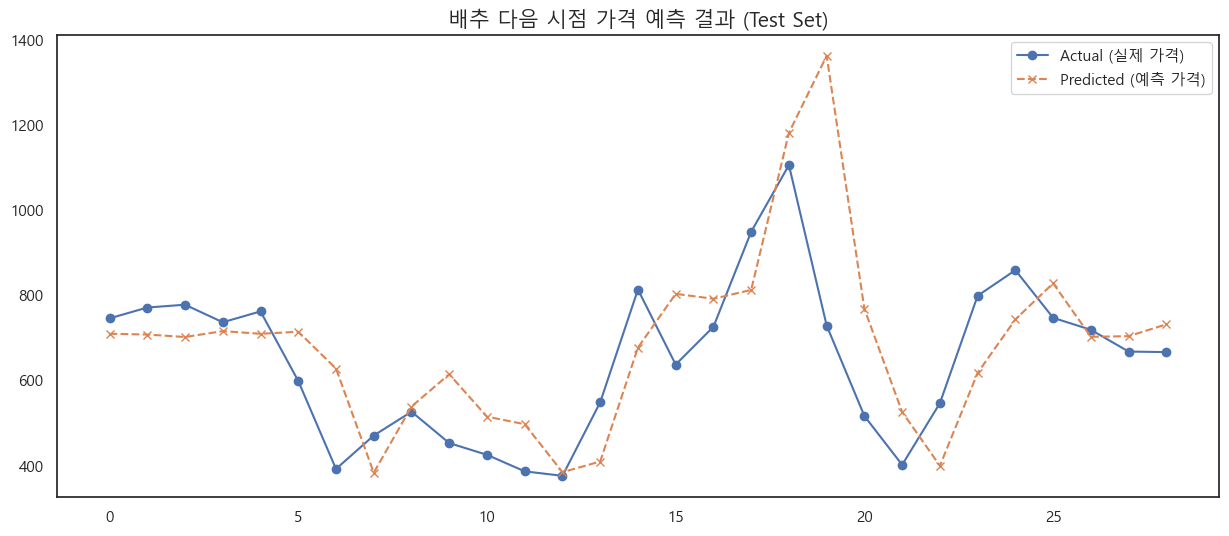

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 학습용 데이터(X)와 정답(y) 분리
# 타겟: '배추'의 현재 가격
target_item = '배추'
y = model_ready_df[target_item]
X = model_ready_df.drop(columns=[target_item]) # 배추 현재가를 제외한 모든 컬럼(Lag 포함)

# 2. 시계열 데이터 특성상 '과거'로 '미래'를 테스트하기 위해 순서대로 분리
# (Shuffle=False가 핵심입니다!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. 모델 생성 및 학습 (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. 예측 및 평가
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 [{target_item}] 예측 모델 성적표")
print(f"- 평균 절대 오차 (MAE): {mae:.2f}원")
print(f"- 결정계수 (R2 Score): {r2:.4f} (1에 가까울수록 정확)")

# 5. 실제값 vs 예측값 시각화
plt.figure(figsize=(15, 6))
plt.plot(y_test.values, label='Actual (실제 가격)', marker='o')
plt.plot(y_pred, label='Predicted (예측 가격)', marker='x', linestyle='--')
plt.title(f'{target_item} 다음 시점 가격 예측 결과 (Test Set)', fontsize=15)
plt.legend()
plt.show() 